# Dyck-k Stack Features for Four Models (50% Noise)

Train `rnn`, `lstm`, `transformer`, and `mamba` on Dyck-k with 50% planted-noise (`24/48/120`), then probe whether their hidden states linearly encode depth, per-type counters, and stack-order information.


## 0. Path Setup


In [2]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

ROOT


PosixPath('/home/hp_twist_shan/Research/Hidden State Evaluation')

## 1. Imports


In [3]:
import importlib.util
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import accuracy_score, mean_absolute_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from hse.experiments.dyck import DEFAULT_DYCK_MODEL_SPECS
from hse.models import build_model
from hse.tasks.dyck_k import DyckKConfig, DyckKSampler, build_prefix_labels
from hse.utils import evaluate_causal_lm, load_yaml, train_causal_lm

try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats('png')
except Exception:
    pass

sns.set_theme(style="whitegrid", context="talk")


/home/hp_twist_shan/miniforge3/envs/hse/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Global Knobs


In [4]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CONFIG_PATH = ROOT / "configs" / "dyck_k_50_noise.yaml"
CONFIG = load_yaml(CONFIG_PATH)
TASK_NAME = CONFIG["experiment"]["name"]
NOTEBOOK_BASE_TASK = dict(CONFIG["task"])
TASK_RUN_NAME = TASK_NAME
BRACKET_TYPES = tuple(NOTEBOOK_BASE_TASK["bracket_types"])
TOTAL_PAIRS = int(NOTEBOOK_BASE_TASK["total_pairs"])
TOTAL_LENGTH = int(NOTEBOOK_BASE_TASK["total_length"])
SEQ_LEN = int(NOTEBOOK_BASE_TASK["seq_len"])
GENERATION_PROB = float(NOTEBOOK_BASE_TASK["generation_prob"])
N_TASKS = int(NOTEBOOK_BASE_TASK["n_tasks"])
PREFIX_PROBE_MAX_LEN = int(NOTEBOOK_BASE_TASK["prefix_probe_max_len"])
TASK_OVERRIDES = {
    "bracket_types": BRACKET_TYPES,
    "total_pairs": TOTAL_PAIRS,
    "total_length": TOTAL_LENGTH,
    "seq_len": SEQ_LEN,
    "generation_prob": GENERATION_PROB,
    "n_tasks": N_TASKS,
    "prefix_probe_max_len": PREFIX_PROBE_MAX_LEN,
}
TASK_TEMPLATE = DyckKConfig(**{**NOTEBOOK_BASE_TASK, **TASK_OVERRIDES, "device": DEVICE})
TYPE_NAMES = list(TASK_TEMPLATE.type_names)
TYPE_NAME_BY_CLASS = {0: "empty", **{i + 1: name for i, name in enumerate(TYPE_NAMES)}}

MODEL_TYPES = ["rnn", "lstm", "transformer", "mamba"]
STATE_KIND_BY_MODEL = {"rnn": "h", "lstm": "c", "transformer": "h", "mamba": "h"}

COMPONENT_TARGETS = [f"height_{name}" for name in TYPE_NAMES]
RIDGE_TARGETS = ["depth"] + COMPONENT_TARGETS
LOGISTIC_TARGETS = [
    "height_vector_class",
    "top_type_class",
    "top_2_class",
    "top_3_class",
    "legal_next_close_type",
    "full_stack_small_class",
]
SHORT_LABEL = {"depth": "depth", **{f"height_{name}": name for name in TYPE_NAMES}}

TRAINING_STEPS = int(CONFIG["training"]["steps"])
BATCH_SIZE = int(CONFIG["training"]["batch_size"])
LEARNING_RATE = float(CONFIG["training"]["learning_rate"])
EVAL_EVERY = 200
TRAIN_SEED = 0

PREFIX_LENGTH = 8
STACK_PROBE_R = 3
FULL_STACK_MAX_DEPTH = 5
DEPTH_SPLIT_THRESHOLD = 3
LAYER_INDEX = -1
N_PROBE_SAMPLES = 20000
PROBE_BATCH_SIZE = 1024
BALANCE_PROBE_BY = CONFIG["analysis"]["probes"]["balance_by"]
BALANCE_SEED = 0
PROBE_MIN_CLASS_COUNT = 32
PROBE_MAX_PER_CLASS = 256
LOGISTIC_MIN_SHARED_COUNT = 8

SANITY_NUM_SAMPLES = 4096
SANITY_BATCH_SIZE = 512
SANITY_PROBE_SAMPLES = 4096
SANITY_PROBE_BATCH_SIZE = 512
SANITY_PROBE_MAX_PER_CLASS = 256

SWEEP_PREFIX_LENGTHS = list(range(2, TOTAL_LENGTH, 2))
SWEEP_N_SAMPLES = 8192

FORCE_RETRAIN = False
EXPERIMENT_TAG = "formal"
RESULTS_ROOT = ROOT / "results" / "notebooks" / "dyck_k_reference_style" / EXPERIMENT_TAG / TASK_RUN_NAME
FIGURES_ROOT = RESULTS_ROOT / "figures"
SAVE_FIGURES = True
SHOW_FIGURES = True
RESULTS_ROOT


PosixPath('/home/hp_twist_shan/Research/Hidden State Evaluation/results/notebooks/dyck_k_reference_style/formal/dyck_k_50_noise')

## 3. Core Helpers


In [5]:
def save_json(obj, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)


def load_json(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def get_task_kwargs():
    task_kwargs = dict(CONFIG["task"])
    task_kwargs.update(TASK_OVERRIDES)
    task_kwargs["device"] = DEVICE
    return task_kwargs


def get_task_config():
    return DyckKConfig(**get_task_kwargs())


def get_model_spec(model_type):
    spec = dict(DEFAULT_DYCK_MODEL_SPECS[model_type])
    if model_type == "lstm":
        spec["state_kind"] = "c"
    return spec


def get_run_dir(model_type):
    return RESULTS_ROOT / f"{model_type}_seed{TRAIN_SEED}"


def build_fresh_model(model_type):
    spec = get_model_spec(model_type)
    model_kwargs = {k: v for k, v in spec.items() if k != "state_kind"}
    cfg = get_task_config()
    return build_model(model_name=model_type, vocab_size=cfg.vocab_size, **model_kwargs).to(DEVICE)


def make_sampler(seed_offset=0):
    return DyckKSampler(get_task_config(), seed=TRAIN_SEED + seed_offset)


def _slug(text):
    return "".join(ch.lower() if ch.isalnum() else "_" for ch in str(text)).strip("_")


def figure_path(section, stem, suffix="png"):
    path = FIGURES_ROOT / section / f"{_slug(stem)}.{suffix}"
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def finalize_figure(fig, *, section, stem, dpi=180):
    saved_path = None
    if SAVE_FIGURES:
        saved_path = figure_path(section, stem)
        fig.savefig(saved_path, dpi=dpi, bbox_inches="tight")
        print(f"saved figure -> {saved_path}")
    if SHOW_FIGURES:
        plt.show()
    plt.close(fig)
    return saved_path


def load_or_train_model(model_type):
    run_dir = get_run_dir(model_type)
    checkpoint_path = run_dir / "checkpoints" / "model_final.pt"
    metrics_path = run_dir / "metrics.json"
    config_path = run_dir / "config.json"

    model = build_fresh_model(model_type)
    train_sampler = make_sampler(seed_offset=0)

    if checkpoint_path.exists() and metrics_path.exists() and not FORCE_RETRAIN:
        payload = torch.load(checkpoint_path, map_location=DEVICE)
        model.load_state_dict(payload["model"])
        return {
            "model": model,
            "train_sampler": train_sampler,
            "metrics": load_json(metrics_path),
            "run_dir": run_dir,
            "config": load_json(config_path) if config_path.exists() else None,
        }

    run_dir.mkdir(parents=True, exist_ok=True)
    spec = get_model_spec(model_type)
    save_json(
        {
            "task_name": TASK_RUN_NAME,
            "base_task_name": TASK_NAME,
            "task_overrides": TASK_OVERRIDES,
            "task": get_task_kwargs(),
            "model_type": model_type,
            "model_spec": spec,
            "training_steps": TRAINING_STEPS,
            "batch_size": BATCH_SIZE,
            "learning_rate": LEARNING_RATE,
            "device": DEVICE,
            "seed": TRAIN_SEED,
        },
        config_path,
    )
    train_log = train_causal_lm(
        model=model,
        sampler=train_sampler,
        steps=TRAINING_STEPS,
        batch_size=BATCH_SIZE,
        lr=LEARNING_RATE,
        run_dir=run_dir,
        eval_every=EVAL_EVERY,
        device=DEVICE,
    )
    eval_metrics = evaluate_causal_lm(
        model=model,
        sampler=make_sampler(seed_offset=100),
        batch_size=BATCH_SIZE,
        device=DEVICE,
    )
    metrics = {"train": train_log, "eval": eval_metrics}
    save_json(metrics, metrics_path)
    return {
        "model": model,
        "train_sampler": train_sampler,
        "metrics": metrics,
        "run_dir": run_dir,
        "config": load_json(config_path),
    }


## 4. Training Sanity Checks


定义训练后的 sanity 分析函数。画 loss 曲线，计算更适合 Dyck-k 的指标，比如 `close_only_acc`、`close_vs_open_acc`、`legal_close_type_acc`，以及一个轻量级的 `top-of-stack` probe。


In [6]:
def moving_average_edge(x, window=11):
    x = np.asarray(x, dtype=float)
    if len(x) < window:
        return x.copy()
    left = window // 2
    right = window - 1 - left
    padded = np.pad(x, (left, right), mode="edge")
    return np.convolve(padded, np.ones(window) / window, mode="valid")


@torch.no_grad()
def compute_close_position_accuracy(model, sampler, *, num_samples=SANITY_NUM_SAMPLES, batch_size=SANITY_BATCH_SIZE):
    cfg = sampler.config
    close_tokens = torch.tensor(cfg.close_tokens, device=DEVICE)
    model.eval().to(DEVICE)
    numer = None
    denom = None
    total_correct = 0.0
    total_count = 0.0
    remaining = int(num_samples)

    while remaining > 0:
        bs = min(int(batch_size), remaining)
        batch = sampler.sample(bs)
        tokens = batch.tokens.to(DEVICE)
        logits = model(tokens)
        pred = logits[:, :-1, :].argmax(dim=-1)
        target = tokens[:, 1:]
        eval_mask = batch.dyck_mask[:, 1:]
        close_mask = torch.isin(target, close_tokens) & eval_mask
        correct = (pred == target) & close_mask

        batch_numer = correct.float().sum(dim=0).detach().cpu()
        batch_denom = close_mask.float().sum(dim=0).detach().cpu()
        numer = batch_numer if numer is None else numer + batch_numer
        denom = batch_denom if denom is None else denom + batch_denom
        total_correct += float(batch_numer.sum())
        total_count += float(batch_denom.sum())
        remaining -= bs

    acc = torch.full_like(denom, float("nan"))
    valid = denom > 0
    acc[valid] = numer[valid] / denom[valid]
    return np.arange(acc.numel()), acc.numpy(), total_correct / max(total_count, 1.0)


def _balance_probe_arrays(X, y, group, *, seed=0, max_per_class=SANITY_PROBE_MAX_PER_CLASS, min_per_class=8):
    group = np.asarray(group)
    classes, counts = np.unique(group, return_counts=True)
    keep = classes[counts >= min_per_class]
    if len(keep) < 2:
        return X, y, group
    rng = np.random.default_rng(seed)
    target = min(int(counts[counts >= min_per_class].min()), int(max_per_class))
    idx_parts = []
    for cls in keep:
        cls_idx = np.flatnonzero(group == cls)
        idx_parts.append(rng.choice(cls_idx, size=target, replace=False))
    idx = np.concatenate(idx_parts)
    rng.shuffle(idx)
    return X[idx], y[idx], group[idx]


def _restrict_shared_probe_classes(X_train, y_train, X_test, y_test, min_count=8):
    train_counts = pd.Series(y_train).value_counts()
    test_counts = pd.Series(y_test).value_counts()
    keep = np.intersect1d(
        train_counts[train_counts >= min_count].index.to_numpy(),
        test_counts[test_counts >= min_count].index.to_numpy(),
    )
    train_mask = np.isin(y_train, keep)
    test_mask = np.isin(y_test, keep)
    return X_train[train_mask], y_train[train_mask], X_test[test_mask], y_test[test_mask]


@torch.no_grad()
def sample_top_probe_dataset(
    model,
    sampler,
    *,
    model_type,
    prefix_length=PREFIX_LENGTH,
    n_samples=SANITY_PROBE_SAMPLES,
    batch_size=SANITY_PROBE_BATCH_SIZE,
):
    cfg = sampler.config
    state_kind = STATE_KIND_BY_MODEL[model_type]
    model.eval().to(DEVICE)
    hs = []
    top = []
    groups = []
    remaining = int(n_samples)

    while remaining > 0:
        bs = min(int(batch_size), remaining)
        batch = sampler.sample(bs)
        tokens = batch.tokens.to(DEVICE)
        dyck_mask = batch.dyck_mask.to(DEVICE)
        states = model.extract_states(tokens, layer_index=LAYER_INDEX, state_kind=state_kind)

        prefix_hits = (dyck_mask.long().cumsum(dim=1) == prefix_length) & dyck_mask
        assert prefix_hits.any(dim=1).all(), "Every sample should contain the requested number of Dyck tokens."
        state_positions = prefix_hits.float().argmax(dim=1)
        row_ids = torch.arange(bs, device=DEVICE)

        labels = build_prefix_labels(batch, config=cfg, max_prefix_len=prefix_length)
        labels = labels.loc[(labels["dyck_seen"] == prefix_length) & (labels["is_dyck_position"])].sort_values("example_id").reset_index(drop=True)
        assert len(labels) == bs, "Expected exactly one prefix label row per sampled example."

        keep = labels["depth"].to_numpy() > 0
        if np.any(keep):
            h = states[row_ids, state_positions, :].detach().cpu().numpy()
            hs.append(h[keep])
            top.append(labels.loc[keep, "top_type_class"].to_numpy())
            groups.append(labels.loc[keep, "depth_top_class"].to_numpy())
        remaining -= bs

    return {
        "h": np.concatenate(hs, axis=0),
        "top_type_class": np.concatenate(top, axis=0),
        "depth_top_class": np.concatenate(groups, axis=0),
    }


def fit_top_probe_sanity(model, *, model_type):
    train_data = sample_top_probe_dataset(model, make_sampler(seed_offset=900), model_type=model_type)
    test_data = sample_top_probe_dataset(model, make_sampler(seed_offset=901), model_type=model_type)
    X_train, y_train, _ = _balance_probe_arrays(
        train_data["h"],
        train_data["top_type_class"],
        train_data["depth_top_class"],
        seed=0,
    )
    X_test, y_test, _ = _balance_probe_arrays(
        test_data["h"],
        test_data["top_type_class"],
        test_data["depth_top_class"],
        seed=1,
    )
    X_train, y_train, X_test, y_test = _restrict_shared_probe_classes(X_train, y_train, X_test, y_test)
    if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
        return {"accuracy": float("nan"), "n_classes": int(len(np.unique(y_train)))}
    probe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000, C=1.0, solver="lbfgs"))
    probe.fit(X_train, y_train)
    pred = probe.predict(X_test)
    return {
        "accuracy": float(accuracy_score(y_test, pred)),
        "n_classes": int(len(np.unique(y_train))),
    }


@torch.no_grad()
def compute_sanity_metrics(model, sampler, *, model_type, num_samples=SANITY_NUM_SAMPLES, batch_size=SANITY_BATCH_SIZE):
    cfg = sampler.config
    close_token_tensor = torch.tensor(cfg.close_tokens, device=DEVICE)
    open_token_tensor = torch.tensor(cfg.open_tokens, device=DEVICE)
    criterion = torch.nn.CrossEntropyLoss(reduction="sum")
    model.eval().to(DEVICE)

    total_loss = 0.0
    total_positions = 0.0
    exact_correct = 0.0
    close_correct = 0.0
    close_count = 0.0
    route_correct = 0.0
    route_count = 0.0
    legal_close_correct = 0.0
    legal_close_count = 0.0
    remaining = int(num_samples)

    while remaining > 0:
        bs = min(int(batch_size), remaining)
        batch = sampler.sample(bs)
        tokens = batch.tokens.to(DEVICE)
        logits = model(tokens)
        step_logits = logits[:, :-1, :]
        target = tokens[:, 1:]
        eval_mask = batch.dyck_mask[:, 1:]

        total_loss += float(criterion(step_logits.reshape(-1, cfg.vocab_size), target.reshape(-1)).item())
        total_positions += float(eval_mask.sum().item())

        pred = step_logits.argmax(dim=-1)
        exact_correct += float(((pred == target) & eval_mask).sum().item())

        close_mask = torch.isin(target, close_token_tensor) & eval_mask
        close_correct += float(((pred == target) & close_mask).sum().item())
        close_count += float(close_mask.sum().item())

        best_open_score = step_logits[:, :, open_token_tensor].max(dim=-1).values
        best_close_score = step_logits[:, :, close_token_tensor].max(dim=-1).values
        pred_is_close = best_close_score > best_open_score
        true_is_close = close_mask
        route_correct += float((pred_is_close[eval_mask] == true_is_close[eval_mask]).sum().item())
        route_count += float(eval_mask.sum().item())

        legal_close_type = torch.tensor(
            build_prefix_labels(batch, config=cfg, max_prefix_len=None)["legal_next_close_type"].to_numpy().reshape(bs, -1),
            device=DEVICE,
            dtype=torch.long,
        )
        nonempty_mask = (legal_close_type > 0) & eval_mask
        pred_close_type = step_logits[:, :, close_token_tensor].argmax(dim=-1) + 1
        legal_close_correct += float((pred_close_type[nonempty_mask] == legal_close_type[nonempty_mask]).sum().item())
        legal_close_count += float(nonempty_mask.sum().item())
        remaining -= bs

    top_probe = fit_top_probe_sanity(model, model_type=model_type)
    return {
        "loss": total_loss / max(total_positions, 1.0),
        "exact_next_token_acc": exact_correct / max(total_positions, 1.0),
        "close_only_acc": close_correct / max(close_count, 1.0),
        "close_vs_open_acc": route_correct / max(route_count, 1.0),
        "legal_close_type_acc": legal_close_correct / max(legal_close_count, 1.0),
        "top_probe_acc": top_probe["accuracy"],
        "top_probe_n_classes": top_probe["n_classes"],
    }


def plot_loss_sanity(model_type, metrics):
    train_df = pd.DataFrame(metrics["train"])
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(train_df["step"], train_df["loss"], lw=0.8, alpha=0.55, label="raw")
    if len(train_df) >= 5:
        smooth = moving_average_edge(train_df["loss"], window=min(11, len(train_df) if len(train_df) % 2 == 1 else len(train_df) - 1))
        axes[0].plot(train_df["step"], smooth, lw=1.6, label="smoothed")
    axes[0].set_title(f"{model_type.upper()} train loss")
    axes[0].set_xlabel("step")
    axes[0].set_ylabel("cross entropy")
    axes[0].legend(frameon=False)
    axes[0].grid(True, alpha=0.25)

    axes[1].plot(train_df["step"], train_df["eval_loss"], label="eval loss", lw=1.8)
    axes[1].axhline(np.log(2 * len(TYPE_NAMES)), color="gray", ls="--", lw=1.0, label=f"log {2 * len(TYPE_NAMES)}")
    axes[1].set_title(f"{model_type.upper()} eval loss")
    axes[1].set_xlabel("step")
    axes[1].set_ylabel("cross entropy")
    axes[1].legend(frameon=False)
    axes[1].grid(True, alpha=0.25)

    plt.tight_layout()
    finalize_figure(fig, section="sanity", stem=f"{model_type}_loss")


def plot_accuracy_sanity(model_type, model):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
    pos, close_pos_acc, close_mean = compute_close_position_accuracy(model, make_sampler(seed_offset=100))
    summary = compute_sanity_metrics(model, make_sampler(seed_offset=101), model_type=model_type)

    axes[0].plot(pos, close_pos_acc, lw=1.8, label=f"close-only mean={close_mean:.3f}")
    axes[0].set_title(f"{model_type.upper()} close-token accuracy by position")
    axes[0].set_xlabel("target position")
    axes[0].set_ylabel("accuracy")
    axes[0].set_ylim(0, 1.02)
    axes[0].legend(frameon=False)
    axes[0].grid(True, alpha=0.25)

    bar_labels = ["exact", "close", "route", "legal-close", "top-probe"]
    bar_values = [
        summary["exact_next_token_acc"],
        summary["close_only_acc"],
        summary["close_vs_open_acc"],
        summary["legal_close_type_acc"],
        summary["top_probe_acc"],
    ]
    axes[1].bar(bar_labels, bar_values, color=["#4C72B0", "#55A868", "#C44E52", "#8172B3", "#CCB974"])
    axes[1].set_title(f"{model_type.upper()} Dyck-k sanity summary")
    axes[1].set_ylabel("accuracy")
    axes[1].set_ylim(0, 1.02)
    axes[1].grid(True, axis="y", alpha=0.25)
    for x, val in enumerate(bar_values):
        axes[1].text(x, min(val + 0.02, 1.01), f"{val:.3f}", ha="center", va="bottom", fontsize=10)

    plt.tight_layout()
    finalize_figure(fig, section="sanity", stem=f"{model_type}_sanity_metrics")
    save_json(summary, get_run_dir(model_type) / "sanity_summary.json")
    print(
        f"{model_type.upper()} sanity -> "
        + ", ".join(
            [
                f"loss={summary['loss']:.4f}",
                f"exact={summary['exact_next_token_acc']:.4f}",
                f"close={summary['close_only_acc']:.4f}",
                f"route={summary['close_vs_open_acc']:.4f}",
                f"legal_close={summary['legal_close_type_acc']:.4f}",
                f"top_probe={summary['top_probe_acc']:.4f}",
            ]
        )
    )
    return summary


In [7]:
loaded_models = {}
sanity_results = {}


## 4A. Train RNN


SANITY: rnn
saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/notebooks/dyck_k_reference_style/formal/dyck_k_50_noise/figures/sanity/rnn_loss.png


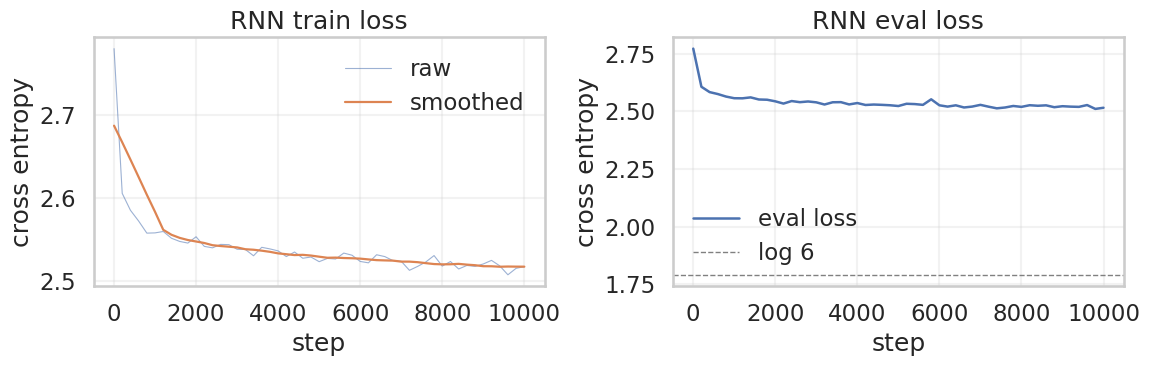

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/notebooks/dyck_k_reference_style/formal/dyck_k_50_noise/figures/sanity/rnn_sanity_metrics.png


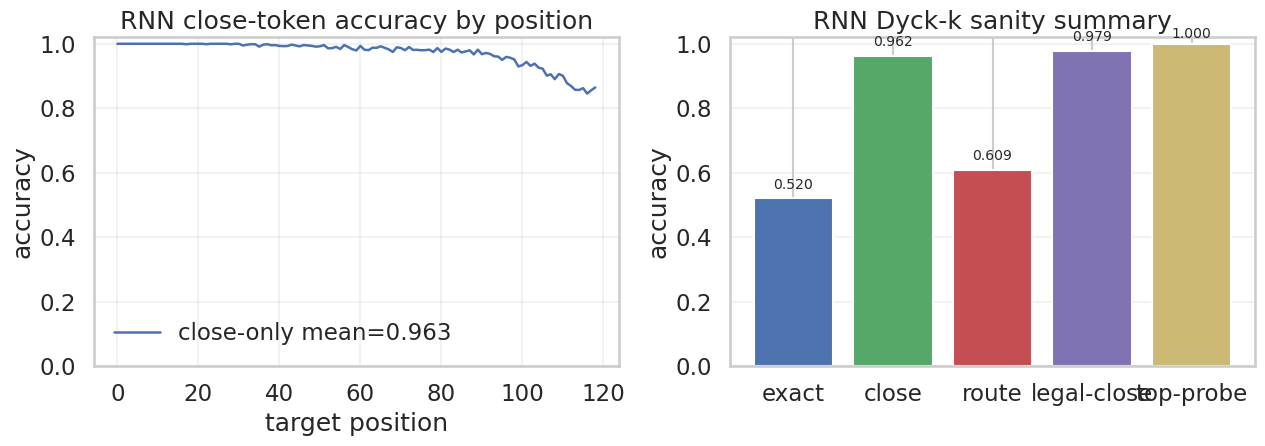

RNN sanity -> loss=6.2773, exact=0.5204, close=0.9625, route=0.6094, legal_close=0.9787, top_probe=1.0000


In [8]:
model_type = "rnn"
print("=" * 80)
print(f"SANITY: {model_type}")
payload = load_or_train_model(model_type)
loaded_models[model_type] = payload
plot_loss_sanity(model_type, payload["metrics"])
sanity_results[model_type] = plot_accuracy_sanity(model_type, payload["model"])


- exact: 整体下一个 token 的完全准确率。
- close: 只在真实下一个 token 本来就是 closing bracket 的位置上算准确率。
- route: 下一个 token 应该是 open 还是 close 的准确率。
- legal-close: 如果现在要 close，那么合法的 close 类型应该是哪一种的准确率。
- top-probe: 先固定在 prefix_length=8 取模型此时的 hidden state，只保留 depth > 0 的样本。也就是栈非空。用一个 LogisticRegression 去预测 top_type_class，即当前栈顶括号类型是 round / square / curly 哪一种的准确率。


## 4B. Train LSTM


SANITY: lstm
saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/notebooks/dyck_k_reference_style/formal/dyck_k_50_noise/figures/sanity/lstm_loss.png


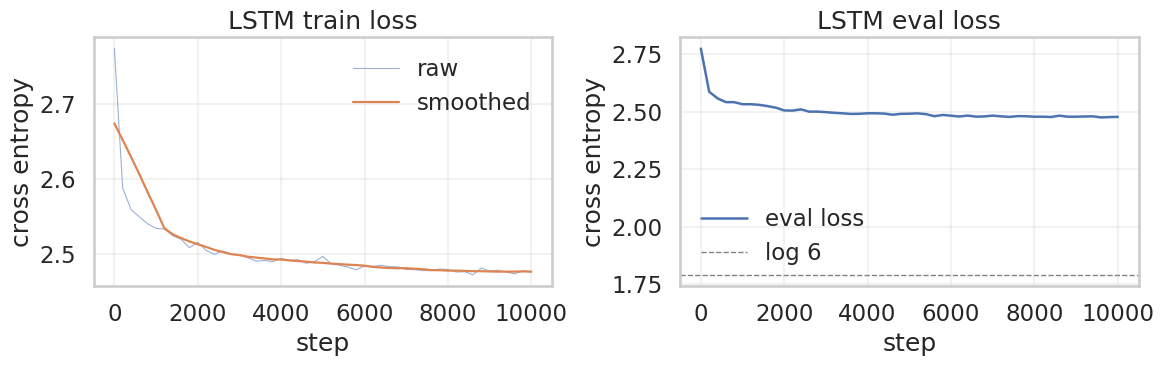

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/notebooks/dyck_k_reference_style/formal/dyck_k_50_noise/figures/sanity/lstm_sanity_metrics.png


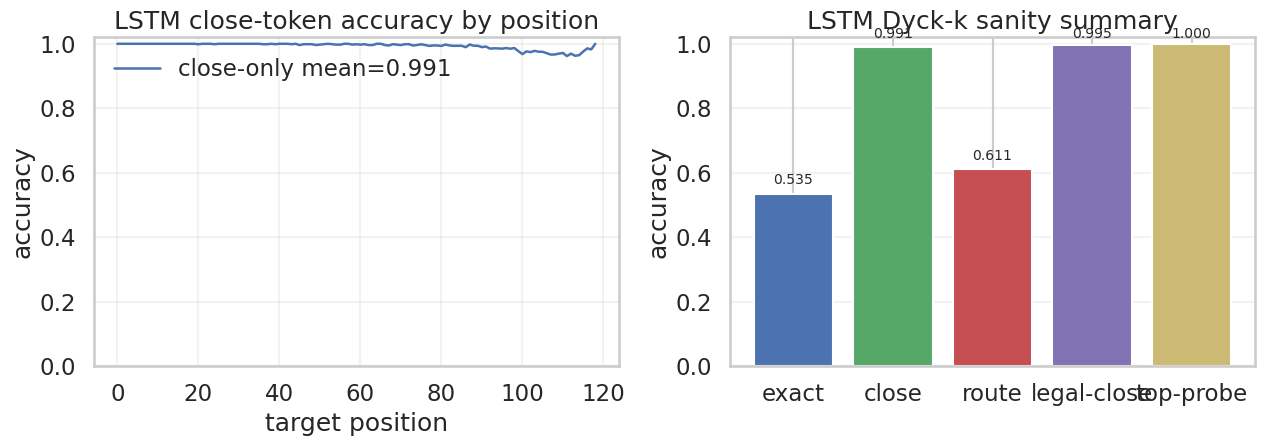

LSTM sanity -> loss=6.1840, exact=0.5353, close=0.9915, route=0.6112, legal_close=0.9951, top_probe=1.0000


In [9]:
model_type = "lstm"
print("=" * 80)
print(f"SANITY: {model_type}")
payload = load_or_train_model(model_type)
loaded_models[model_type] = payload
plot_loss_sanity(model_type, payload["metrics"])
sanity_results[model_type] = plot_accuracy_sanity(model_type, payload["model"])


## 4C. Train Transformer


SANITY: transformer
saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/notebooks/dyck_k_reference_style/formal/dyck_k_50_noise/figures/sanity/transformer_loss.png


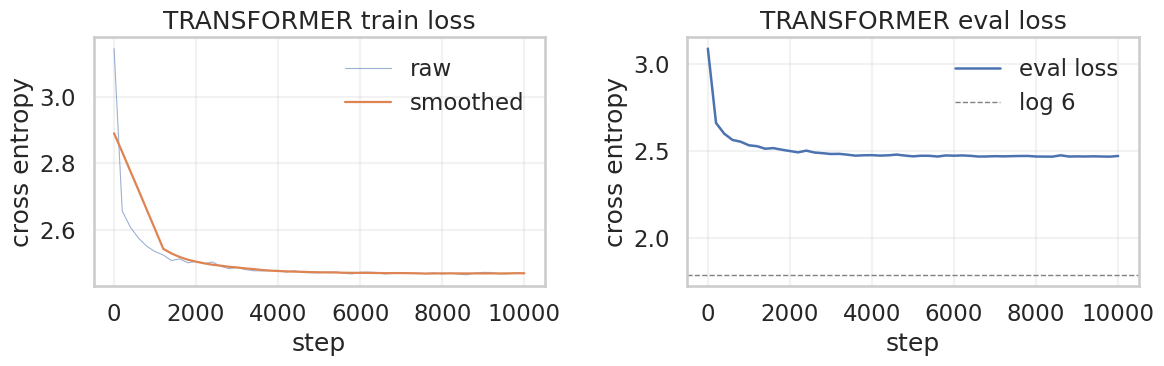

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/notebooks/dyck_k_reference_style/formal/dyck_k_50_noise/figures/sanity/transformer_sanity_metrics.png


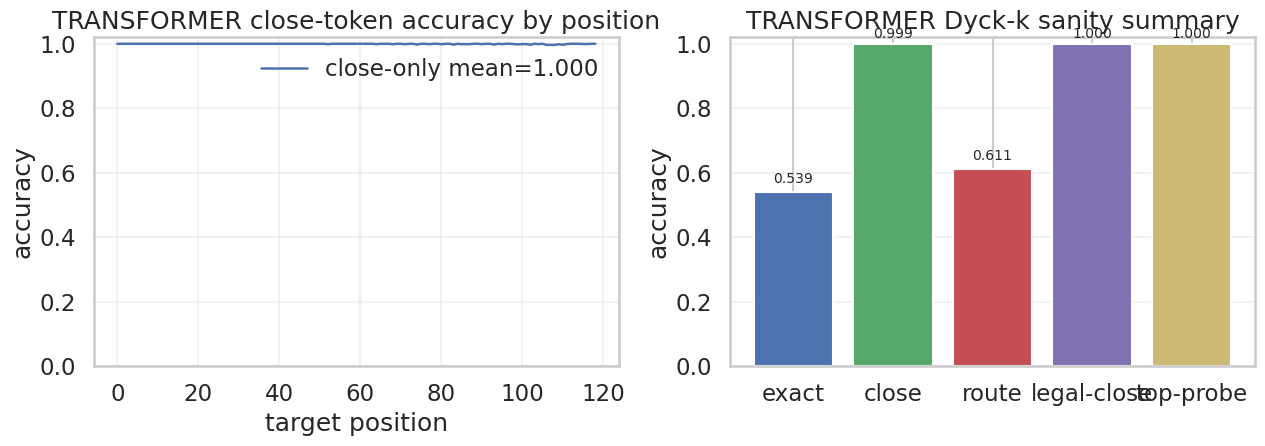

TRANSFORMER sanity -> loss=6.1691, exact=0.5388, close=0.9994, route=0.6112, legal_close=0.9998, top_probe=1.0000


In [10]:
model_type = "transformer"
print("=" * 80)
print(f"SANITY: {model_type}")
payload = load_or_train_model(model_type)
loaded_models[model_type] = payload
plot_loss_sanity(model_type, payload["metrics"])
sanity_results[model_type] = plot_accuracy_sanity(model_type, payload["model"])


## 4D. Train Mamba


SANITY: mamba
saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/notebooks/dyck_k_reference_style/formal/dyck_k_50_noise/figures/sanity/mamba_loss.png


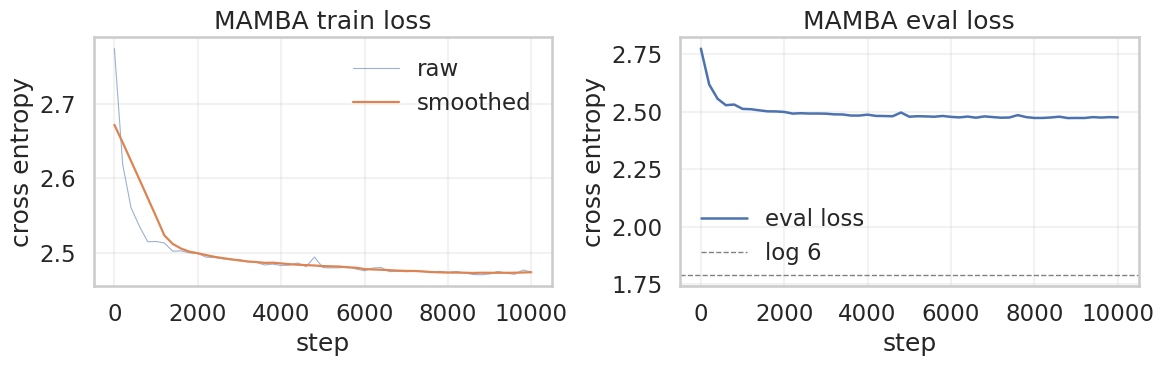

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/notebooks/dyck_k_reference_style/formal/dyck_k_50_noise/figures/sanity/mamba_sanity_metrics.png


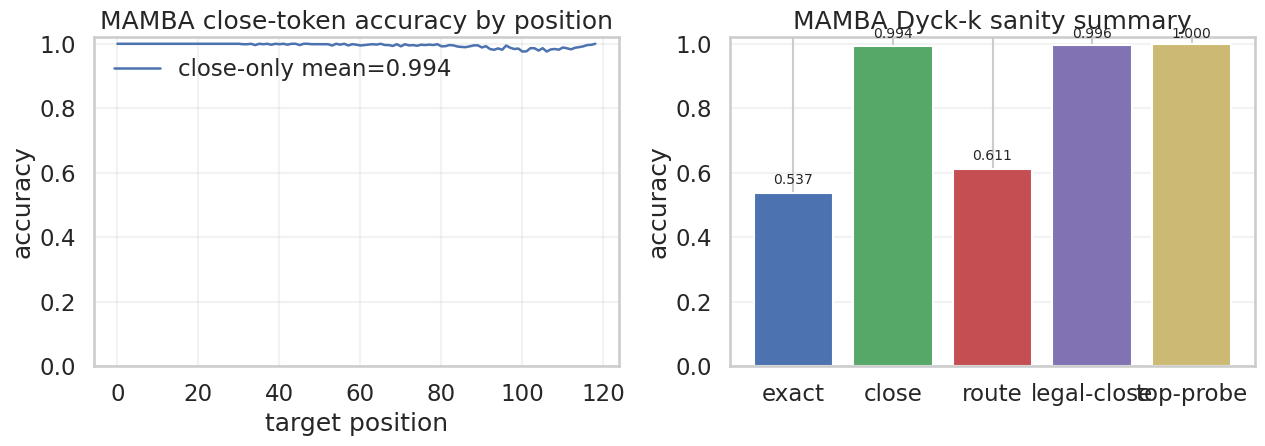

MAMBA sanity -> loss=6.1805, exact=0.5367, close=0.9939, route=0.6112, legal_close=0.9964, top_probe=1.0000


In [11]:
model_type = "mamba"
print("=" * 80)
print(f"SANITY: {model_type}")
payload = load_or_train_model(model_type)
loaded_models[model_type] = payload
plot_loss_sanity(model_type, payload["metrics"])
sanity_results[model_type] = plot_accuracy_sanity(model_type, payload["model"])


## 5. Stack Probe Data and Probe Fitting


从固定的 Dyck-prefix 长度处抽 hidden state，配上 `depth / per-type heights / height_vector / top / top-2 / top-3 / legal_next_close / full_stack_small_class` 标签，按 `depth_top_class` 做类别平衡，再分别拟合 ridge 与 logistic probe。

50-noise 版本里，`prefix_length` 指的是“已经见过多少个 Dyck token”，不是绝对序列位置；所以这里会先找到每个样本里第 `prefix_length` 个括号真正落在 120 长序列的哪个位置，再去对齐 hidden state 和标签。


In [12]:
@torch.no_grad()
def sample_hidden_stack_matrix(
    model,
    sampler,
    *,
    prefix_length=PREFIX_LENGTH,
    layer_index=LAYER_INDEX,
    state_kind="h",
    n_samples=N_PROBE_SAMPLES,
    batch_size=PROBE_BATCH_SIZE,
):
    cfg = sampler.config
    assert 1 <= prefix_length <= cfg.total_length
    model.eval().to(DEVICE)

    hs = []
    prefixes = []
    scalar_targets = {target: [] for target in RIDGE_TARGETS}
    discrete_targets = {
        "height_vector_class": [],
        "top_type_class": [],
        "top_2_class": [],
        "top_3_class": [],
        "legal_next_close_type": [],
        "depth_top_class": [],
    }
    stack_reprs = []
    full_stack_small = []
    height_vectors = []
    remaining = int(n_samples)

    while remaining > 0:
        bs = min(int(batch_size), remaining)
        batch = sampler.sample(bs)
        tokens = batch.tokens.to(DEVICE)
        dyck_mask = batch.dyck_mask.to(DEVICE)
        states = model.extract_states(tokens, layer_index=layer_index, state_kind=state_kind)

        prefix_hits = (dyck_mask.long().cumsum(dim=1) == prefix_length) & dyck_mask
        assert prefix_hits.any(dim=1).all(), "Every sample should contain the requested number of Dyck tokens."
        state_positions = prefix_hits.float().argmax(dim=1)
        row_ids = torch.arange(bs, device=DEVICE)
        hs.append(states[row_ids, state_positions, :].detach().cpu().numpy())

        bracket_tokens = torch.empty(bs, cfg.total_length, dtype=torch.long, device=DEVICE)
        for type_id, (open_tok, close_tok) in enumerate(zip(cfg.open_tokens, cfg.close_tokens)):
            is_type = batch.bracket_type_ids == type_id
            bracket_tokens[is_type] = torch.where(
                batch.dyck_steps[is_type] > 0,
                torch.full_like(batch.dyck_steps[is_type], open_tok),
                torch.full_like(batch.dyck_steps[is_type], close_tok),
            )
        prefixes.append(bracket_tokens[:, :prefix_length].detach().cpu().numpy())

        labels = build_prefix_labels(batch, config=cfg, max_prefix_len=prefix_length)
        labels = labels.loc[(labels["dyck_seen"] == prefix_length) & (labels["is_dyck_position"])].sort_values("example_id").reset_index(drop=True)
        assert len(labels) == bs, "Expected exactly one prefix label row per sampled example."
        for target in RIDGE_TARGETS:
            scalar_targets[target].append(labels[target].to_numpy())
        for target in discrete_targets:
            discrete_targets[target].append(labels[target].to_numpy())

        stack_values = labels["stack_repr"].to_numpy()
        depth_values = labels["depth"].to_numpy()
        stack_reprs.append(stack_values)
        full_stack_small.append(np.where(depth_values <= FULL_STACK_MAX_DEPTH, stack_values, "__overflow__"))
        height_vectors.append(np.stack([labels[target].to_numpy() for target in COMPONENT_TARGETS], axis=1))
        remaining -= bs

    data = {
        "h": np.concatenate(hs, axis=0),
        "prefix": np.concatenate(prefixes, axis=0),
        "stack_repr": np.concatenate(stack_reprs, axis=0),
        "full_stack_small_class": np.concatenate(full_stack_small, axis=0),
        "height_vector": np.concatenate(height_vectors, axis=0),
    }
    for target, parts in scalar_targets.items():
        data[target] = np.concatenate(parts, axis=0)
    for target, parts in discrete_targets.items():
        data[target] = np.concatenate(parts, axis=0)
    return data


def balance_data_by_label(data, label="depth_top_class", seed=0, max_per_class=PROBE_MAX_PER_CLASS, min_per_class=PROBE_MIN_CLASS_COUNT):
    if label is None or label not in data:
        return data
    y = np.asarray(data[label])
    classes, counts = np.unique(y, return_counts=True)
    keep_classes = classes[counts >= min_per_class]
    if len(keep_classes) <= 1:
        return data

    keep_mask = np.isin(y, keep_classes)
    filtered = {k: np.asarray(v)[keep_mask] for k, v in data.items()}
    y = np.asarray(filtered[label])
    classes, counts = np.unique(y, return_counts=True)
    target = int(counts.min()) if max_per_class is None else min(int(counts.min()), int(max_per_class))

    rng = np.random.default_rng(seed)
    idx_parts = []
    for cls in classes:
        cls_idx = np.flatnonzero(y == cls)
        idx_parts.append(rng.choice(cls_idx, size=target, replace=False))
    idx = np.concatenate(idx_parts)
    rng.shuffle(idx)
    return {k: np.asarray(v)[idx] for k, v in filtered.items()}


def print_class_balance(data, label="depth_top_class", name="data", limit=12):
    classes, counts = np.unique(np.asarray(data[label]), return_counts=True)
    order = np.argsort(counts)[::-1]
    parts = [f"{classes[i]}:{int(counts[i])}" for i in order[:limit]]
    suffix = " ..." if len(order) > limit else ""
    print(f"{name} {label} counts -> " + ", ".join(parts) + suffix)


def fit_ridge_probe(X_train, y_train, X_test, y_test, name):
    probe = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
    probe.fit(X_train, y_train)
    pred = probe.predict(X_test)
    return {
        "name": name,
        "probe": probe,
        "r2": float(r2_score(y_test, pred)),
        "mae": float(mean_absolute_error(y_test, pred)),
    }


def fit_vector_ridge_probe(X_train, y_train, X_test, y_test, name):
    probe = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
    probe.fit(X_train, y_train)
    pred = probe.predict(X_test)
    return {
        "name": name,
        "probe": probe,
        "r2_mean": float(r2_score(y_test, pred, multioutput="uniform_average")),
        "r2_var_weighted": float(r2_score(y_test, pred, multioutput="variance_weighted")),
        "mae": float(mean_absolute_error(y_test, pred)),
        "per_dim_r2": r2_score(y_test, pred, multioutput="raw_values"),
    }


def restrict_to_shared_classes(X_train, y_train, X_test, y_test, min_count=LOGISTIC_MIN_SHARED_COUNT):
    train_counts = pd.Series(y_train).value_counts()
    test_counts = pd.Series(y_test).value_counts()
    keep = np.intersect1d(
        train_counts[train_counts >= min_count].index.to_numpy(),
        test_counts[test_counts >= min_count].index.to_numpy(),
    )
    train_mask = np.isin(y_train, keep)
    test_mask = np.isin(y_test, keep)
    return X_train[train_mask], y_train[train_mask], X_test[test_mask], y_test[test_mask]


def fit_logistic_probe(X_train, y_train, X_test, y_test, name):
    X_train_use, y_train_use, X_test_use, y_test_use = restrict_to_shared_classes(X_train, y_train, X_test, y_test)
    train_classes = np.unique(y_train_use)
    test_classes = np.unique(y_test_use)
    if len(train_classes) < 2 or len(test_classes) < 2:
        return {"name": name, "probe": None, "accuracy": float("nan"), "n_classes": int(len(train_classes))}
    probe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=4000, C=1.0, solver="lbfgs"))
    probe.fit(X_train_use, y_train_use)
    pred = probe.predict(X_test_use)
    return {
        "name": name,
        "probe": probe,
        "accuracy": float(accuracy_score(y_test_use, pred)),
        "n_classes": int(len(train_classes)),
    }


def run_stack_probes(train_data, test_data):
    X_train = train_data["h"]
    X_test = test_data["h"]
    rows = []
    fitted = {}

    for target in RIDGE_TARGETS:
        out = fit_ridge_probe(X_train, train_data[target], X_test, test_data[target], target)
        fitted[f"ridge_{target}"] = out["probe"]
        rows.append({"probe": "ridge", "target": target, "metric": "r2", "value": out["r2"]})
        rows.append({"probe": "ridge", "target": target, "metric": "mae", "value": out["mae"]})

    vector_out = fit_vector_ridge_probe(X_train, train_data["height_vector"], X_test, test_data["height_vector"], "height_vector")
    fitted["ridge_height_vector"] = vector_out["probe"]
    rows.append({"probe": "ridge", "target": "height_vector", "metric": "r2_mean", "value": vector_out["r2_mean"]})
    rows.append({"probe": "ridge", "target": "height_vector", "metric": "r2_var_weighted", "value": vector_out["r2_var_weighted"]})
    rows.append({"probe": "ridge", "target": "height_vector", "metric": "mae", "value": vector_out["mae"]})
    for target, value in zip(COMPONENT_TARGETS, vector_out["per_dim_r2"]):
        rows.append({"probe": "ridge", "target": f"{target}_joint", "metric": "r2", "value": float(value)})

    for target in LOGISTIC_TARGETS:
        out = fit_logistic_probe(X_train, train_data[target], X_test, test_data[target], target)
        fitted[f"logistic_{target}"] = out["probe"]
        rows.append({"probe": "logistic", "target": target, "metric": "accuracy", "value": out["accuracy"]})
        rows.append({"probe": "logistic", "target": target, "metric": "n_classes", "value": out["n_classes"]})

    return rows, fitted


def _normalize(v):
    return v / (np.linalg.norm(v) + 1e-12)


def _ridge_direction(ridge_pipeline):
    scaler = ridge_pipeline.named_steps["standardscaler"]
    ridge = ridge_pipeline.named_steps["ridge"]
    return ridge.coef_ / scaler.scale_


def _project_on_ridge_direction(X, ridge_pipeline, center=True, standardize=True):
    direction = _normalize(_ridge_direction(ridge_pipeline))
    X_use = X - X.mean(axis=0, keepdims=True) if center else X
    z = X_use @ direction
    if standardize:
        z = (z - z.mean()) / (z.std() + 1e-12)
    return z


def _logistic_score_embedding(X, logistic_pipeline):
    if logistic_pipeline is None:
        return None
    scaler = logistic_pipeline.named_steps["standardscaler"]
    clf = logistic_pipeline.named_steps["logisticregression"]
    scores = clf.decision_function(scaler.transform(X))
    if scores.ndim == 1:
        scores = np.stack([-scores, scores], axis=1)
    if scores.shape[1] <= 2:
        return scores[:, :2]
    return PCA(n_components=2).fit_transform(scores)


def summarize_stack_directions(fitted):
    directions = {target: _normalize(_ridge_direction(fitted[f"ridge_{target}"])) for target in RIDGE_TARGETS}
    print("direction cosine summary")
    for a, b in [(COMPONENT_TARGETS[0], COMPONENT_TARGETS[1]), (COMPONENT_TARGETS[0], COMPONENT_TARGETS[2]), (COMPONENT_TARGETS[1], COMPONENT_TARGETS[2])]:
        print(f"  cos({SHORT_LABEL[a]}, {SHORT_LABEL[b]}) = {np.dot(directions[a], directions[b]):+.4f}")
    sum_direction = _normalize(sum(directions[target] for target in COMPONENT_TARGETS))
    print(f"  cos(depth, normalized component sum) = {np.dot(directions['depth'], sum_direction):+.4f}")


## 6. PCA Views by Depth and Counters


1. 用 PCA 粗看 hidden state 的全局结构。
2. 主证据仍然来自 supervised probes；PCA 只作为 sanity check。


depth: 当前 prefix 读完之后，未闭合括号的总数，即栈深度。
- `plot_depth_counter_pca_panels`：用 PCA 粗看 hidden state 的整体几何结构，并按 `depth` 或各类 counter 上色。
- `plot_stack_order_given_counts`：固定同一个 counter 组合，只看不同 `stack order` 是否还能被 hidden state 区分。
- `plot_stack_projection_panels`：把 hidden state 投影到学到的方向上，直接看 `depth`、`top-type` 等变量是否接近线性可分。
- `plot_direction_cosine_heatmap`：看不同读出方向之间的余弦相似度，判断表征是更解耦还是更纠缠。
这里的 `prefix` 在 50-noise 版本里仍然是按 Dyck token 数量定义，不是 120 长序列里的绝对位置。


In [13]:
def _prefix_to_symbols(prefix_row, cfg):
    tok_to_symbol = {}
    for pair, open_tok, close_tok in zip(cfg.bracket_types, cfg.open_tokens, cfg.close_tokens):
        tok_to_symbol[open_tok] = pair[0]
        tok_to_symbol[close_tok] = pair[1]
    return "".join(tok_to_symbol.get(int(tok), "·") for tok in prefix_row)


def _stack_repr_to_symbols(stack_repr, cfg):
    if stack_repr == "empty":
        return "empty"
    open_by_name = {name: pair[0] for name, pair in zip(cfg.type_names, cfg.bracket_types)}
    return "".join(open_by_name.get(name, "?") for name in str(stack_repr).split("|"))


def plot_depth_counter_pca_panels(data, *, title, save_stem, max_points=5000):
    X = np.asarray(data["h"])
    idx = np.arange(len(X))
    if len(idx) > max_points:
        rng = np.random.default_rng(0)
        idx = rng.choice(idx, size=max_points, replace=False)
    X = X[idx]
    X2 = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(X))

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    plot_targets = ["depth"] + COMPONENT_TARGETS[:3]
    cmaps = ["viridis", "coolwarm", "coolwarm", "coolwarm"]
    for ax, target, cmap in zip(axes.ravel(), plot_targets, cmaps):
        sc = ax.scatter(X2[:, 0], X2[:, 1], c=np.asarray(data[target])[idx], s=12, alpha=0.65, cmap=cmap, linewidths=0)
        ax.set_title(f"{title} | color={SHORT_LABEL.get(target, target)}")
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.grid(True, alpha=0.25)
        fig.colorbar(sc, ax=ax, shrink=0.82)
    plt.tight_layout()
    finalize_figure(fig, section="probe_views", stem=save_stem)


def _scatter_by_top_type(ax, x, y, labels, *, title, xlabel, ylabel):
    classes = sorted(pd.unique(labels))
    cmap = plt.get_cmap("tab10", max(len(classes), 1))
    for i, cls in enumerate(classes):
        mask = labels == cls
        ax.scatter(
            x[mask],
            y[mask],
            s=14,
            alpha=0.65,
            linewidths=0,
            color=cmap(i),
            label=TYPE_NAME_BY_CLASS.get(int(cls), str(cls)),
        )
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.25)
    ax.legend(frameon=False, fontsize=9)


def plot_stack_order_given_counts(data, *, title, save_stem, max_points_per_stack=250):
    count_classes = np.asarray(data["height_vector_class"])
    stack_reprs = np.asarray(data["stack_repr"])
    X = np.asarray(data["h"])

    summary = []
    for cls in np.unique(count_classes):
        mask = count_classes == cls
        unique_stacks = np.unique(stack_reprs[mask])
        if len(unique_stacks) >= 2:
            summary.append((len(unique_stacks), int(mask.sum()), cls))
    if not summary:
        print("No count-vector class has at least two distinct stack orders at this prefix.")
        return

    _, _, chosen = max(summary)
    mask = count_classes == chosen
    X_sub = X[mask]
    stack_sub = stack_reprs[mask]
    X2 = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(X_sub))

    idx_by_stack = {stack: np.flatnonzero(stack_sub == stack) for stack in np.unique(stack_sub)}
    fig, ax = plt.subplots(figsize=(8.5, 7.0))
    cmap = plt.get_cmap("tab20", max(len(idx_by_stack), 1))
    vector_desc = ", ".join(f"{SHORT_LABEL[target]}={int(np.asarray(data[target])[mask][0])}" for target in COMPONENT_TARGETS)

    for i, (stack_name, idx) in enumerate(sorted(idx_by_stack.items())):
        centroid = X2[idx].mean(axis=0)
        ax.scatter(
            [centroid[0]],
            [centroid[1]],
            s=110,
            alpha=0.95,
            linewidths=0.8,
            edgecolors="black",
            color=cmap(i),
            label=_stack_repr_to_symbols(stack_name, TASK_TEMPLATE),
        )

    ax.set_title(f"{title}\nfixed counters: {vector_desc}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.25)
    ax.legend(frameon=False, fontsize=9, loc="best", title="stack (top->bottom)")
    plt.tight_layout()
    finalize_figure(fig, section="probe_views", stem=save_stem)


def plot_stack_projection_panels(data, fitted, *, title, save_stem, max_points=5000):
    X = np.asarray(data["h"])
    idx = np.arange(len(X))
    if len(idx) > max_points:
        rng = np.random.default_rng(1)
        idx = rng.choice(idx, size=max_points, replace=False)

    projections = {target: _project_on_ridge_direction(X, fitted[f"ridge_{target}"])[idx] for target in RIDGE_TARGETS}
    top_type = np.asarray(data["top_type_class"])[idx]
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    axes[0, 0].scatter(np.asarray(data["depth"])[idx], projections["depth"], s=12, alpha=0.55, linewidths=0)
    axes[0, 0].set_xlabel("true depth")
    axes[0, 0].set_ylabel("projection on depth direction")
    axes[0, 0].set_title(f"{title} | depth readout")
    axes[0, 0].grid(True, alpha=0.25)

    _scatter_by_top_type(
        axes[0, 1],
        projections[COMPONENT_TARGETS[0]],
        projections[COMPONENT_TARGETS[1]],
        top_type,
        title=f"proj {SHORT_LABEL[COMPONENT_TARGETS[0]]} vs {SHORT_LABEL[COMPONENT_TARGETS[1]]}",
        xlabel=f"proj {SHORT_LABEL[COMPONENT_TARGETS[0]]}",
        ylabel=f"proj {SHORT_LABEL[COMPONENT_TARGETS[1]]}",
    )
    _scatter_by_top_type(
        axes[1, 0],
        projections[COMPONENT_TARGETS[0]],
        projections[COMPONENT_TARGETS[2]],
        top_type,
        title=f"proj {SHORT_LABEL[COMPONENT_TARGETS[0]]} vs {SHORT_LABEL[COMPONENT_TARGETS[2]]}",
        xlabel=f"proj {SHORT_LABEL[COMPONENT_TARGETS[0]]}",
        ylabel=f"proj {SHORT_LABEL[COMPONENT_TARGETS[2]]}",
    )

    top_scores = _logistic_score_embedding(X, fitted.get("logistic_top_type_class"))
    if top_scores is None:
        axes[1, 1].text(0.5, 0.5, "top-type logistic probe unavailable", ha="center", va="center")
        axes[1, 1].set_axis_off()
    else:
        top_scores = top_scores[idx]
        _scatter_by_top_type(
            axes[1, 1],
            top_scores[:, 0],
            top_scores[:, 1],
            top_type,
            title=f"{title} | top-type score space",
            xlabel="score dim 1",
            ylabel="score dim 2",
        )

    plt.tight_layout()
    finalize_figure(fig, section="probe_views", stem=save_stem)


def plot_direction_cosine_heatmap(fitted, *, title, save_stem):
    direction_targets = ["depth"] + COMPONENT_TARGETS
    directions = {target: _normalize(_ridge_direction(fitted[f"ridge_{target}"])) for target in direction_targets}
    mat = np.zeros((len(direction_targets), len(direction_targets)))
    for i, a in enumerate(direction_targets):
        for j, b in enumerate(direction_targets):
            mat[i, j] = float(np.dot(directions[a], directions[b]))
    labels = [SHORT_LABEL[target] for target in direction_targets]
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    sns.heatmap(mat, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(title)
    plt.tight_layout()
    finalize_figure(fig, section="probe_views", stem=save_stem)


## 7. Structured Memory Views


MODEL: rnn
rnn train raw depth_top_class counts -> 0:5609, 9:2924, 11:2856, 10:2823, 19:1472, 18:1466, 17:1427, 25:429, 26:426, 27:406, 35:61, 33:54 ...
rnn test raw depth_top_class counts -> 0:5417, 9:2932, 11:2913, 10:2897, 17:1538, 19:1457, 18:1453, 27:418, 26:413, 25:402, 35:58, 34:55 ...
rnn train balanced depth_top_class counts -> 35:47, 34:47, 33:47, 27:47, 26:47, 25:47, 19:47, 18:47, 17:47, 11:47, 10:47, 9:47 ...
rnn test balanced depth_top_class counts -> 35:47, 34:47, 33:47, 27:47, 26:47, 25:47, 19:47, 18:47, 17:47, 11:47, 10:47, 9:47 ...
   ridge                  depth           r2: 0.9335
   ridge                  depth          mae: 0.4965
   ridge           height_round           r2: 0.9531
   ridge           height_round          mae: 0.1946
   ridge          height_square           r2: 0.8931
   ridge          height_square          mae: 0.3030
   ridge           height_curly           r2: 0.9258
   ridge           height_curly          mae: 0.2645
   ridge          hei

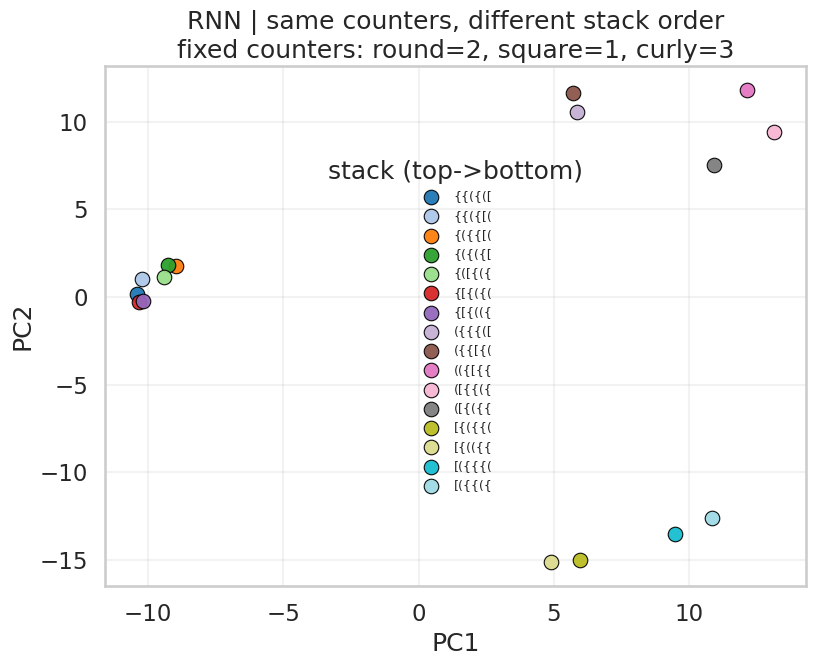

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/notebooks/dyck_k_reference_style/formal/dyck_k_50_noise/figures/probe_views/rnn_pca_prefix_8.png


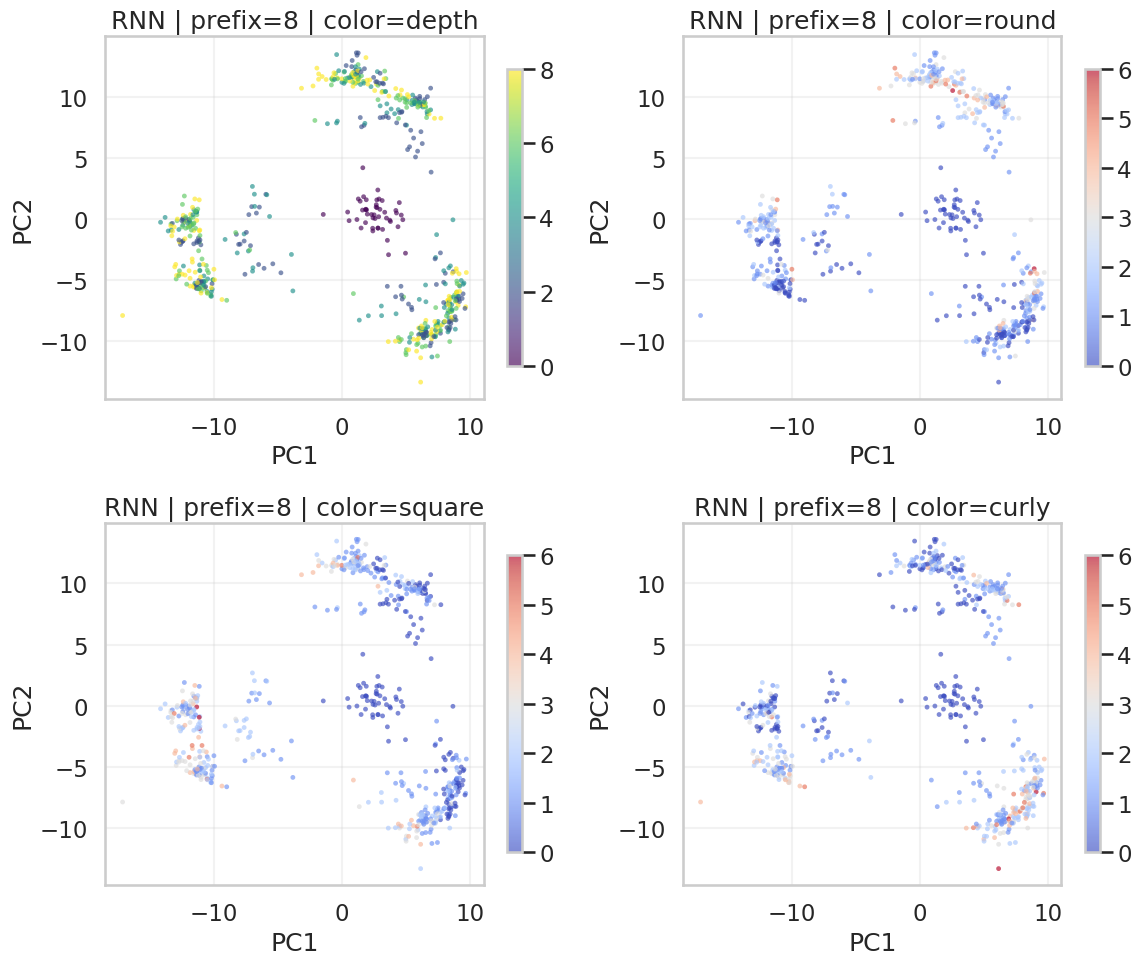

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/notebooks/dyck_k_reference_style/formal/dyck_k_50_noise/figures/probe_views/rnn_projection_prefix_8.png


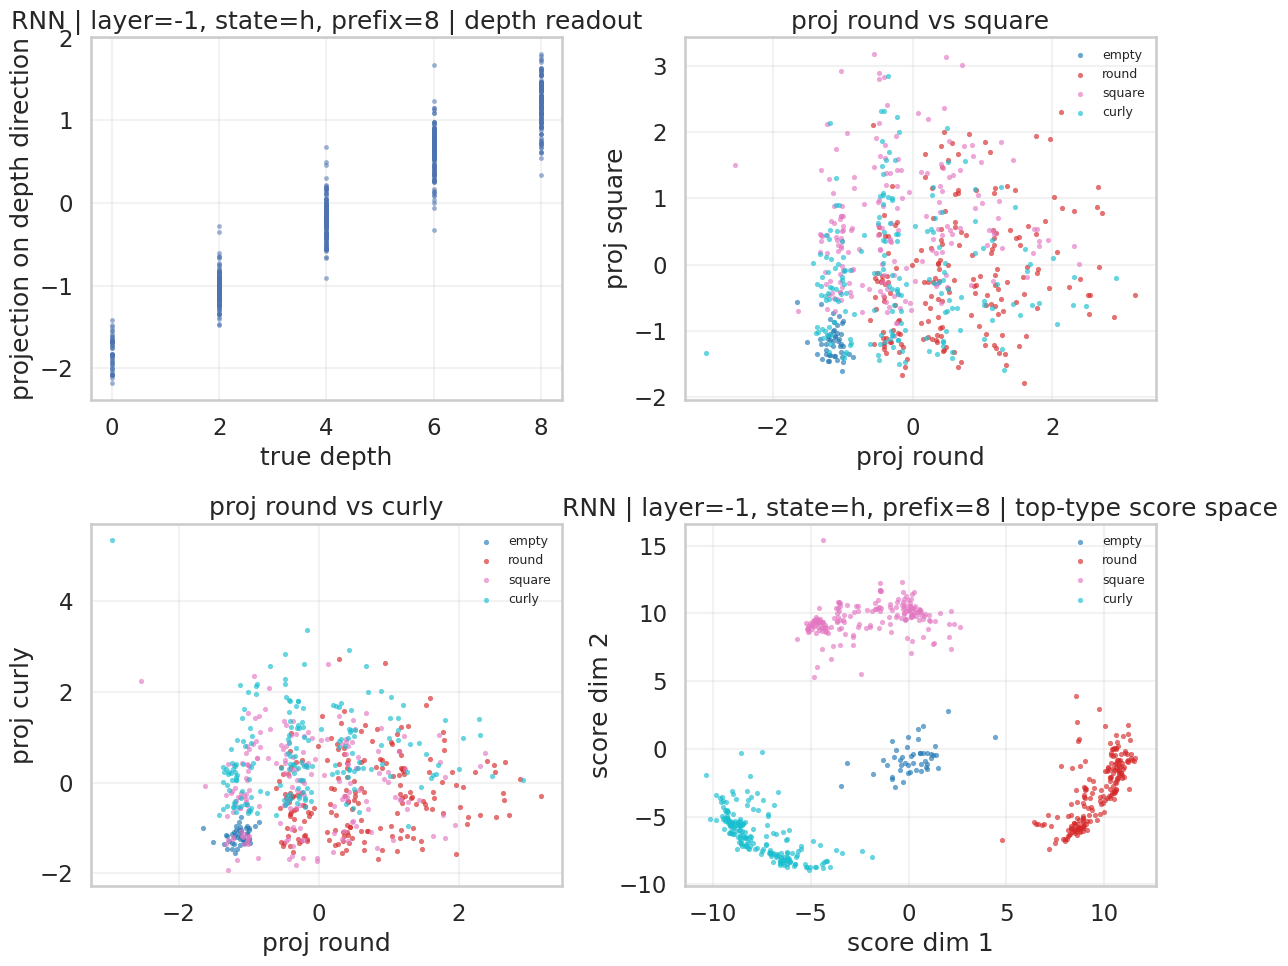

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/notebooks/dyck_k_reference_style/formal/dyck_k_50_noise/figures/probe_views/rnn_direction_heatmap_prefix_8.png


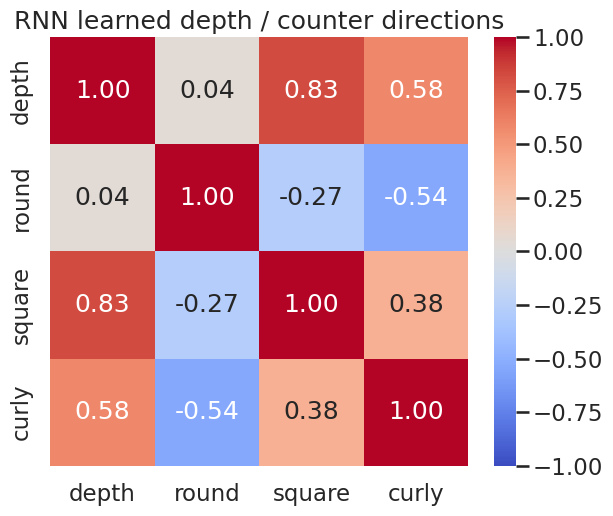

MODEL: lstm
lstm train raw depth_top_class counts -> 0:5609, 9:2924, 11:2856, 10:2823, 19:1472, 18:1466, 17:1427, 25:429, 26:426, 27:406, 35:61, 33:54 ...
lstm test raw depth_top_class counts -> 0:5417, 9:2932, 11:2913, 10:2897, 17:1538, 19:1457, 18:1453, 27:418, 26:413, 25:402, 35:58, 34:55 ...
lstm train balanced depth_top_class counts -> 35:47, 34:47, 33:47, 27:47, 26:47, 25:47, 19:47, 18:47, 17:47, 11:47, 10:47, 9:47 ...
lstm test balanced depth_top_class counts -> 35:47, 34:47, 33:47, 27:47, 26:47, 25:47, 19:47, 18:47, 17:47, 11:47, 10:47, 9:47 ...
   ridge                  depth           r2: 0.9799
   ridge                  depth          mae: 0.2833
   ridge           height_round           r2: 0.9493
   ridge           height_round          mae: 0.2298
   ridge          height_square           r2: 0.9048
   ridge          height_square          mae: 0.3001
   ridge           height_curly           r2: 0.8825
   ridge           height_curly          mae: 0.3544
   ridge        

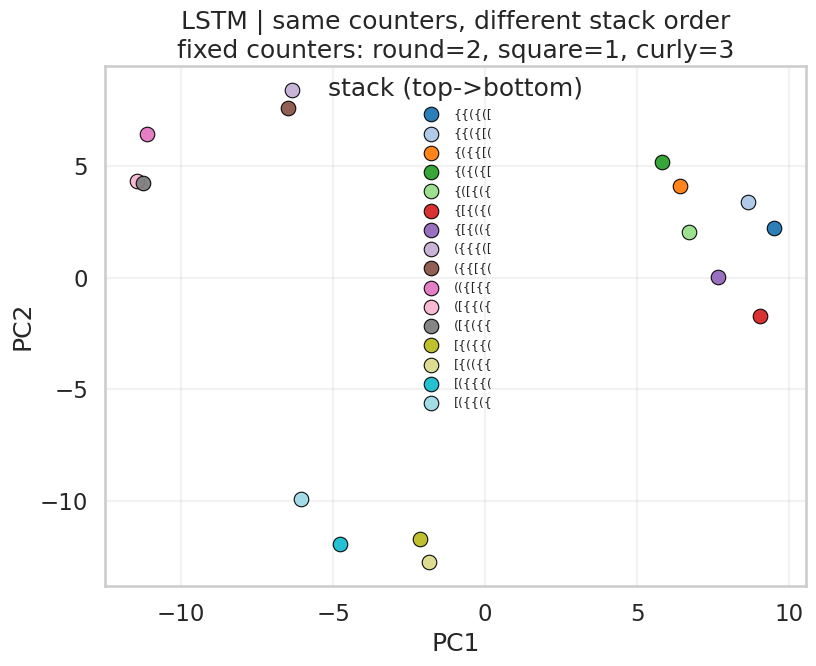

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/notebooks/dyck_k_reference_style/formal/dyck_k_50_noise/figures/probe_views/lstm_pca_prefix_8.png


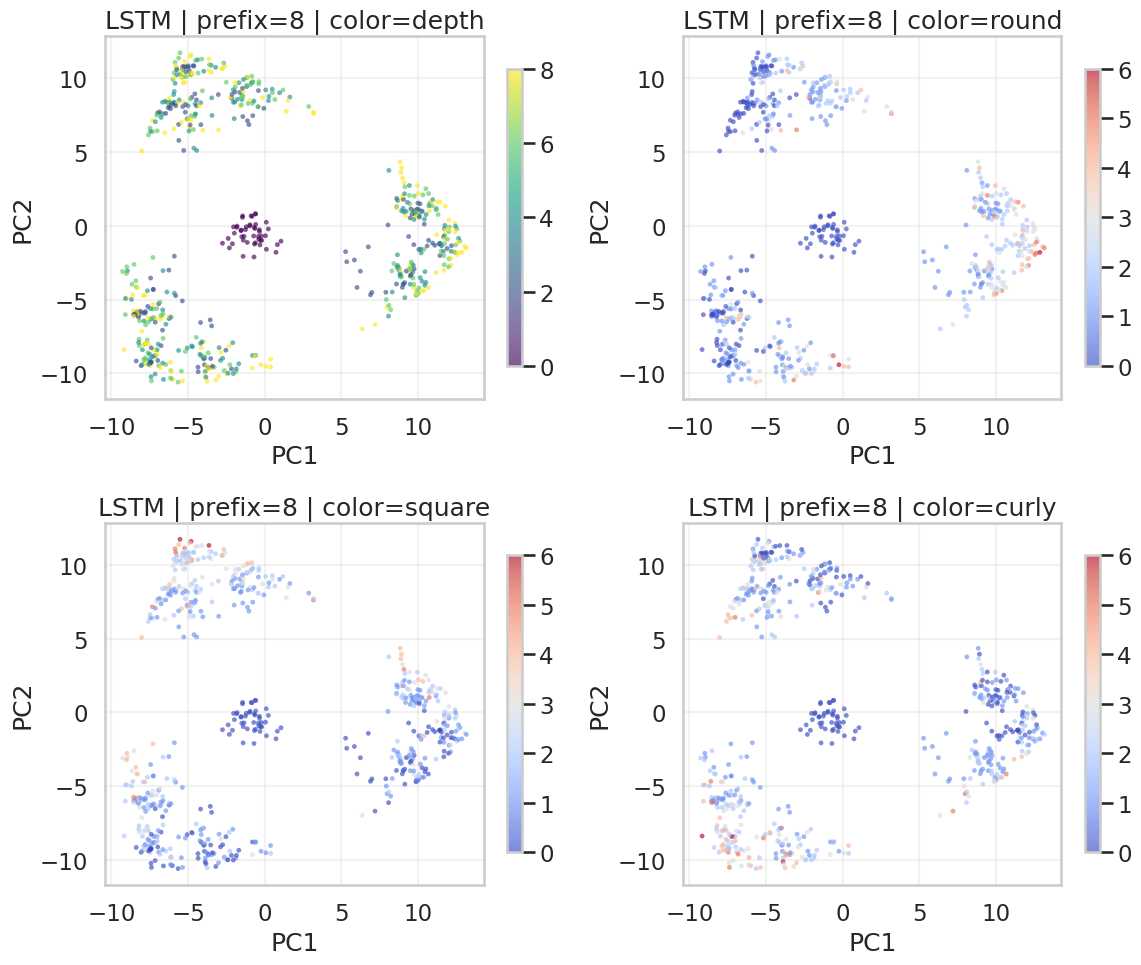

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/notebooks/dyck_k_reference_style/formal/dyck_k_50_noise/figures/probe_views/lstm_projection_prefix_8.png


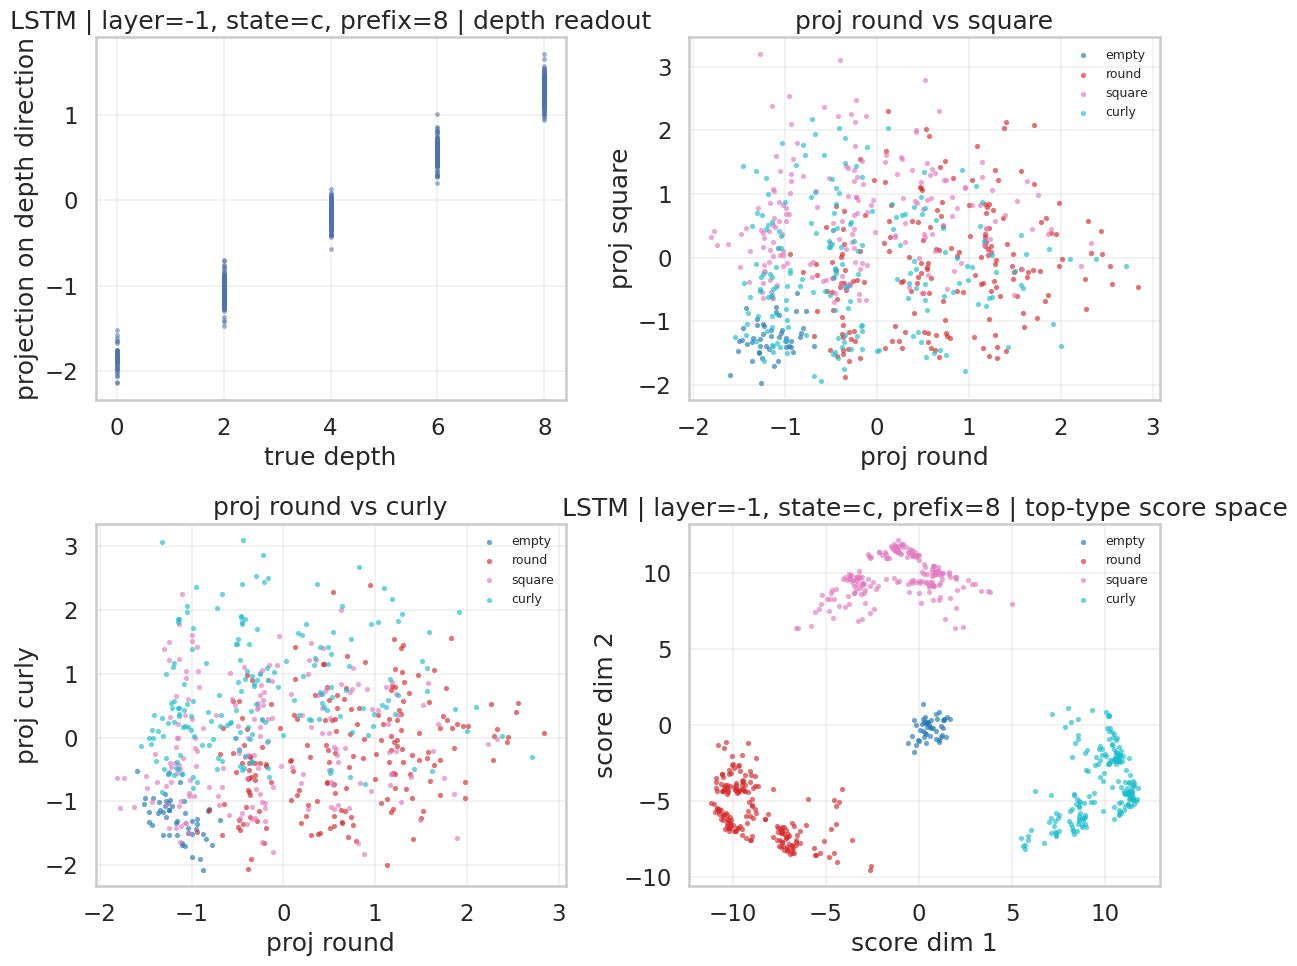

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/notebooks/dyck_k_reference_style/formal/dyck_k_50_noise/figures/probe_views/lstm_direction_heatmap_prefix_8.png


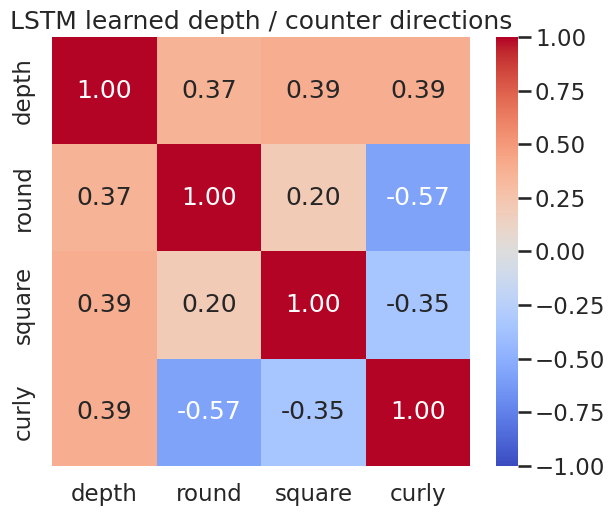

MODEL: transformer
transformer train raw depth_top_class counts -> 0:5609, 9:2924, 11:2856, 10:2823, 19:1472, 18:1466, 17:1427, 25:429, 26:426, 27:406, 35:61, 33:54 ...
transformer test raw depth_top_class counts -> 0:5417, 9:2932, 11:2913, 10:2897, 17:1538, 19:1457, 18:1453, 27:418, 26:413, 25:402, 35:58, 34:55 ...
transformer train balanced depth_top_class counts -> 35:47, 34:47, 33:47, 27:47, 26:47, 25:47, 19:47, 18:47, 17:47, 11:47, 10:47, 9:47 ...
transformer test balanced depth_top_class counts -> 35:47, 34:47, 33:47, 27:47, 26:47, 25:47, 19:47, 18:47, 17:47, 11:47, 10:47, 9:47 ...
   ridge                  depth           r2: 0.9946
   ridge                  depth          mae: 0.1416
   ridge           height_round           r2: 0.9905
   ridge           height_round          mae: 0.0975
   ridge          height_square           r2: 0.9908
   ridge          height_square          mae: 0.0908
   ridge           height_curly           r2: 0.9920
   ridge           height_curly   

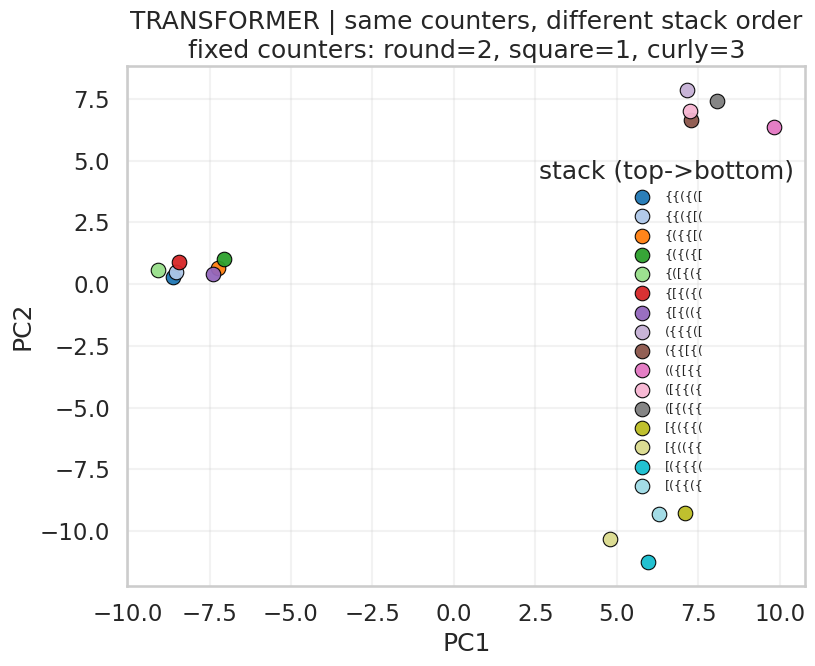

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/notebooks/dyck_k_reference_style/formal/dyck_k_50_noise/figures/probe_views/transformer_pca_prefix_8.png


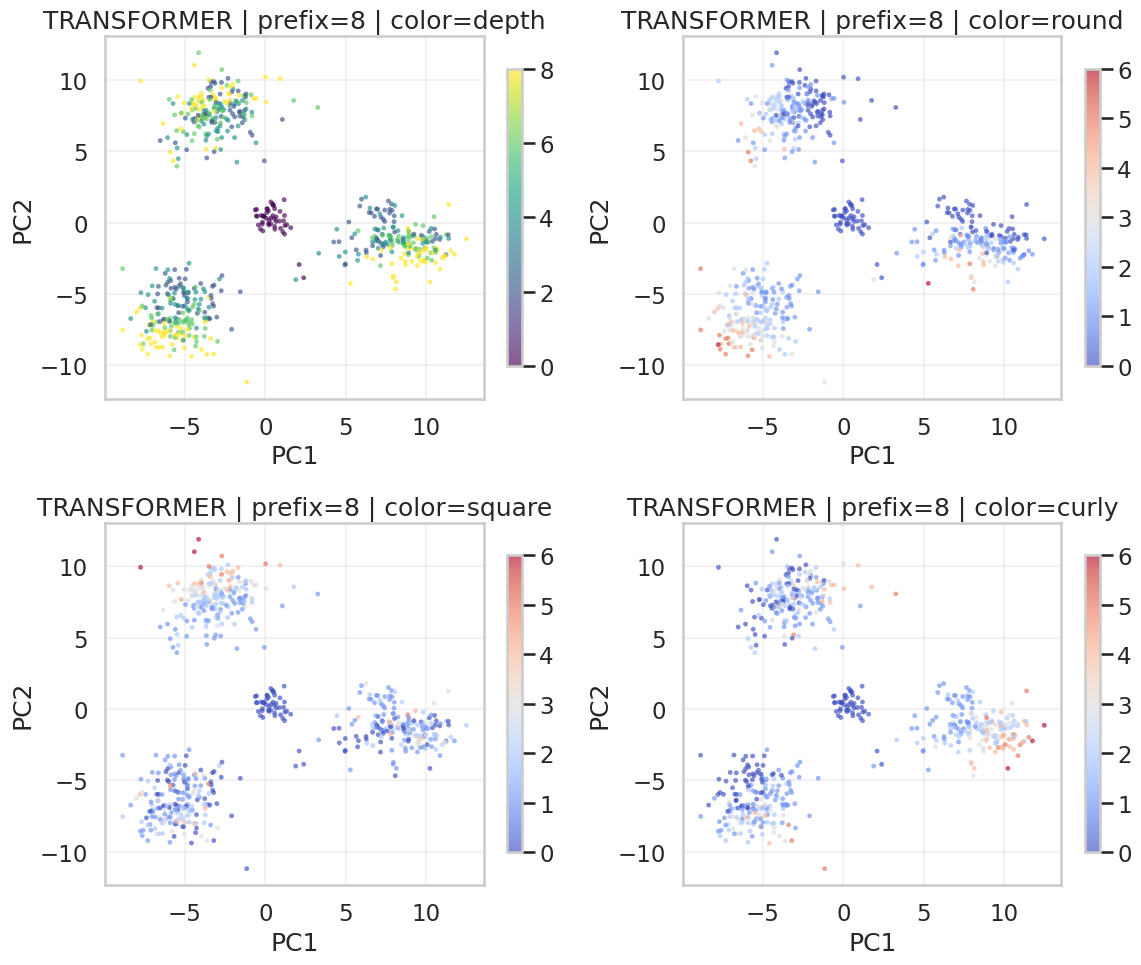

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/notebooks/dyck_k_reference_style/formal/dyck_k_50_noise/figures/probe_views/transformer_projection_prefix_8.png


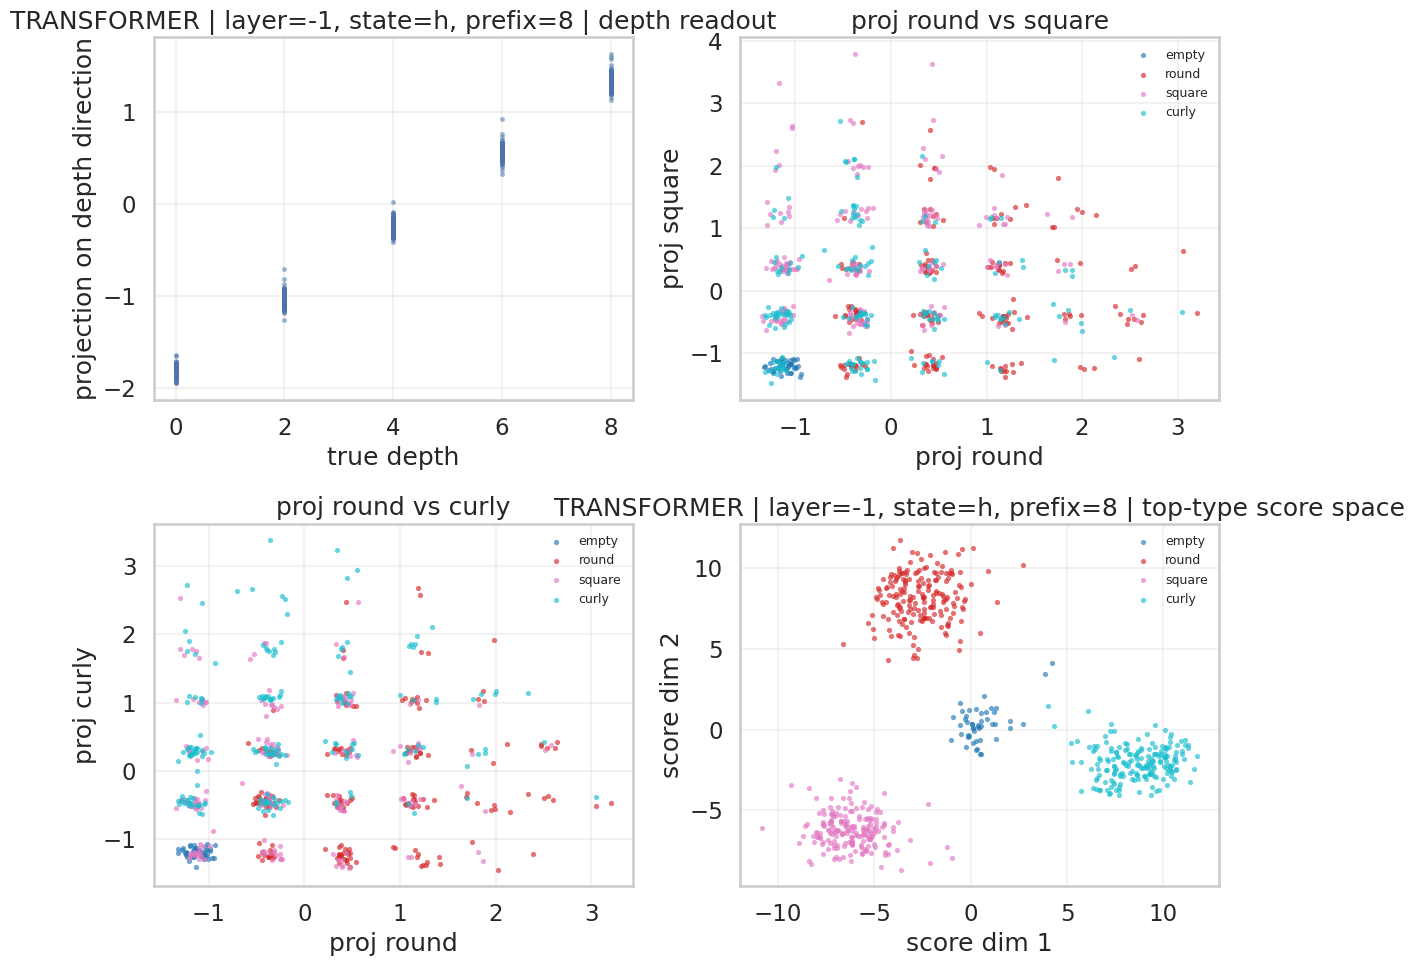

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/notebooks/dyck_k_reference_style/formal/dyck_k_50_noise/figures/probe_views/transformer_direction_heatmap_prefix_8.png


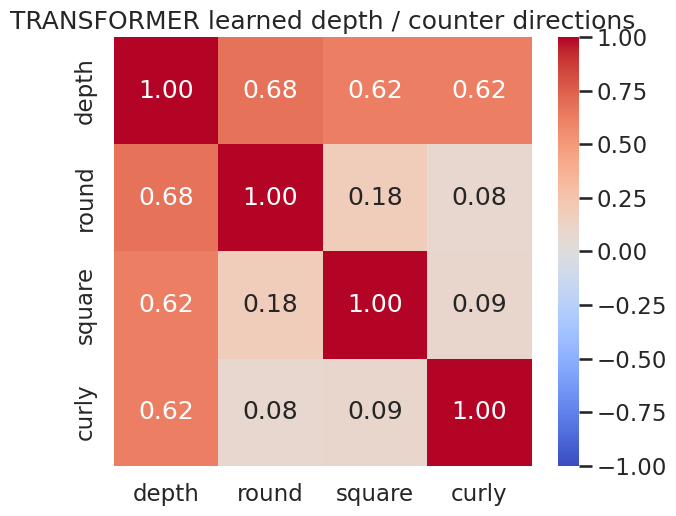

MODEL: mamba
mamba train raw depth_top_class counts -> 0:5609, 9:2924, 11:2856, 10:2823, 19:1472, 18:1466, 17:1427, 25:429, 26:426, 27:406, 35:61, 33:54 ...
mamba test raw depth_top_class counts -> 0:5417, 9:2932, 11:2913, 10:2897, 17:1538, 19:1457, 18:1453, 27:418, 26:413, 25:402, 35:58, 34:55 ...
mamba train balanced depth_top_class counts -> 35:47, 34:47, 33:47, 27:47, 26:47, 25:47, 19:47, 18:47, 17:47, 11:47, 10:47, 9:47 ...
mamba test balanced depth_top_class counts -> 35:47, 34:47, 33:47, 27:47, 26:47, 25:47, 19:47, 18:47, 17:47, 11:47, 10:47, 9:47 ...
   ridge                  depth           r2: 0.8963
   ridge                  depth          mae: 0.6275
   ridge           height_round           r2: 0.8145
   ridge           height_round          mae: 0.4411
   ridge          height_square           r2: 0.8601
   ridge          height_square          mae: 0.3597
   ridge           height_curly           r2: 0.8157
   ridge           height_curly          mae: 0.4212
   ridge   

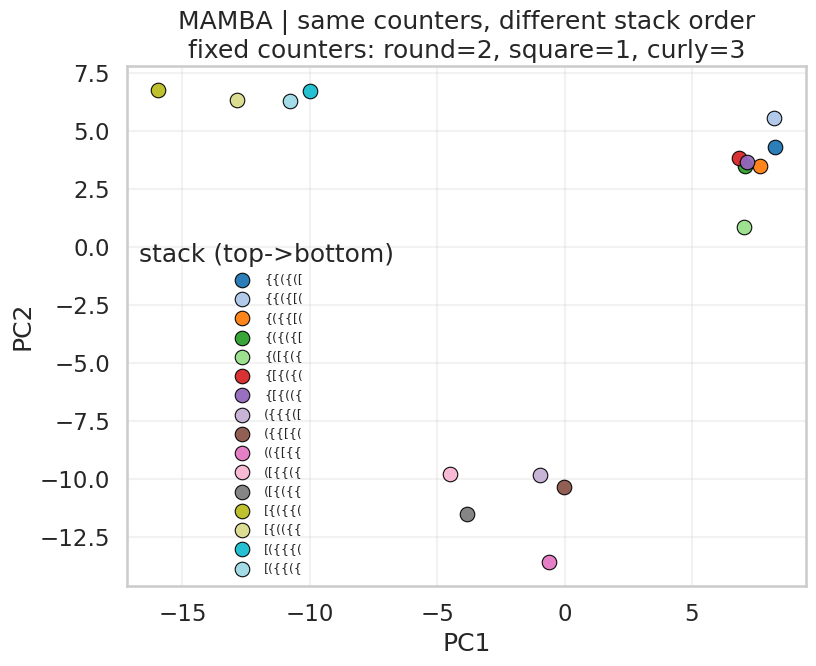

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/notebooks/dyck_k_reference_style/formal/dyck_k_50_noise/figures/probe_views/mamba_pca_prefix_8.png


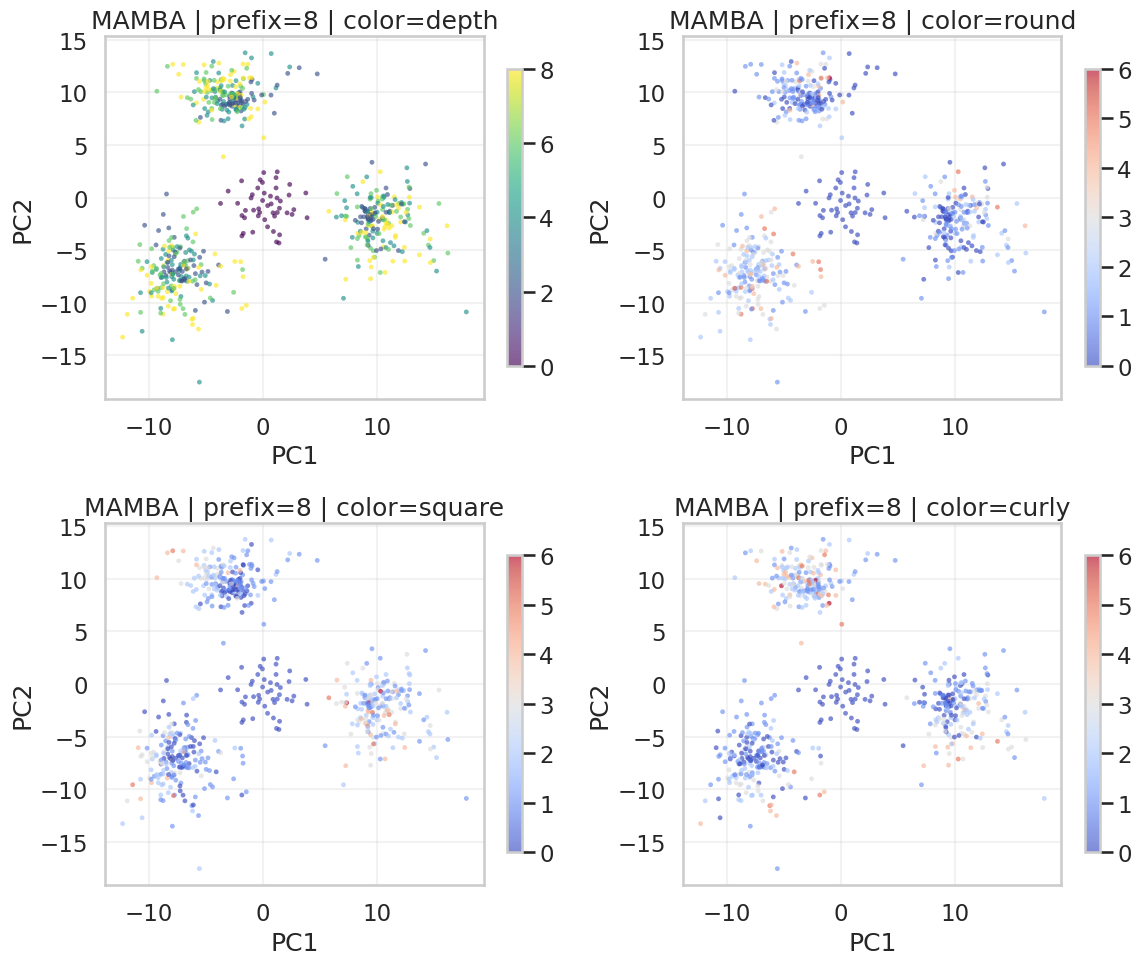

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/notebooks/dyck_k_reference_style/formal/dyck_k_50_noise/figures/probe_views/mamba_projection_prefix_8.png


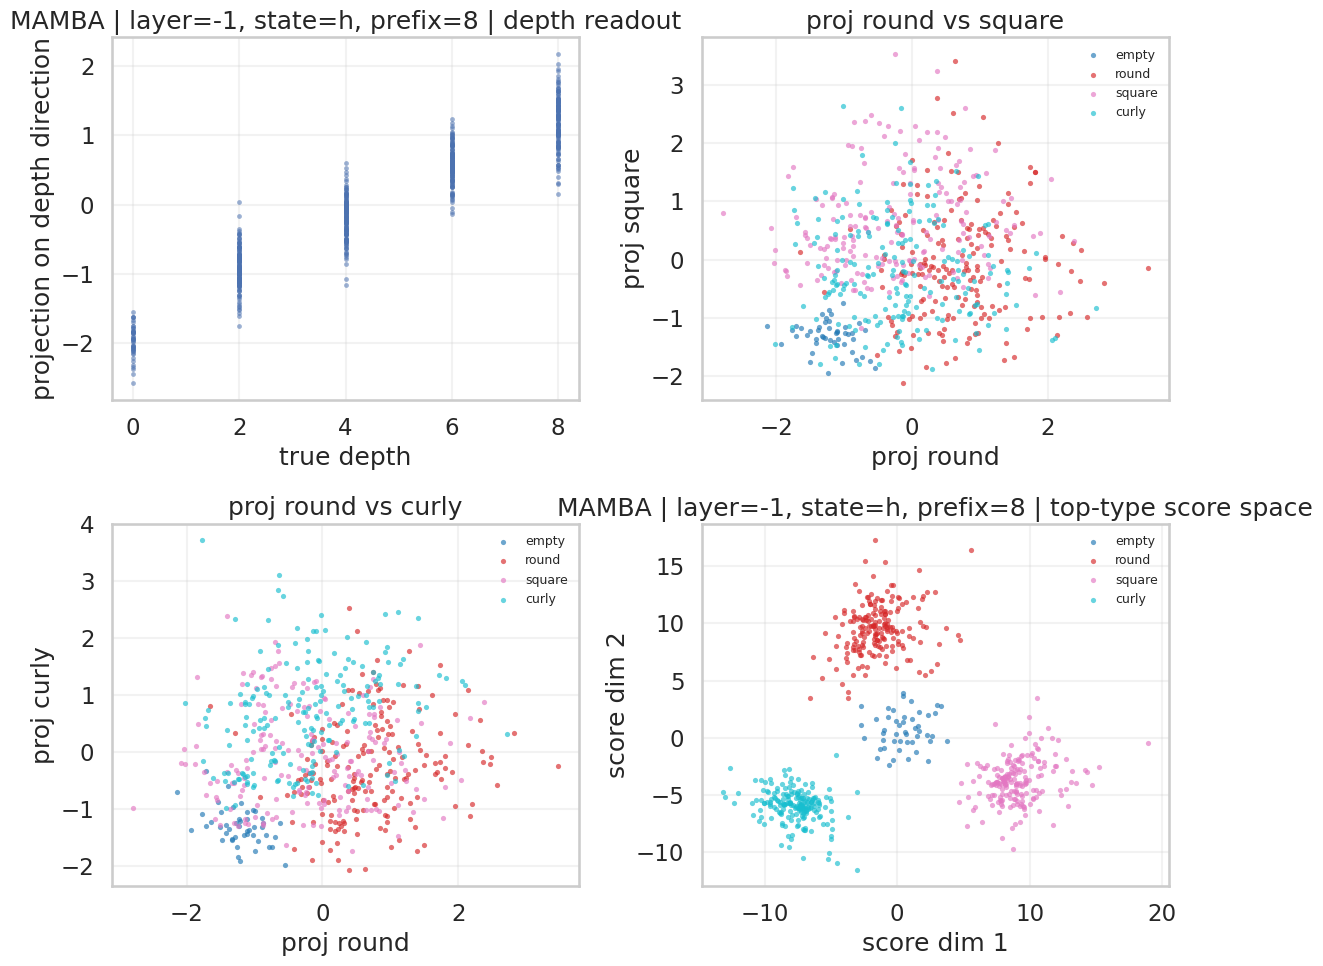

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/notebooks/dyck_k_reference_style/formal/dyck_k_50_noise/figures/probe_views/mamba_direction_heatmap_prefix_8.png


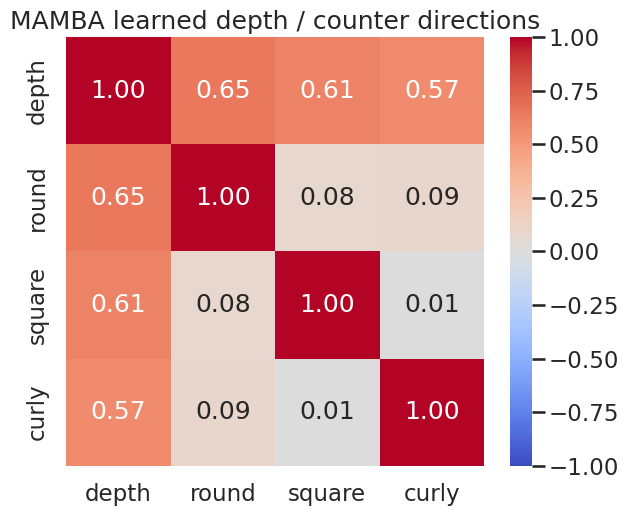

In [14]:
all_results = {}

for model_type in MODEL_TYPES:
    print("=" * 80)
    print(f"MODEL: {model_type}")
    payload = loaded_models[model_type]
    model = payload["model"]
    state_kind = STATE_KIND_BY_MODEL[model_type]

    train_data = sample_hidden_stack_matrix(
        model,
        make_sampler(seed_offset=300),
        prefix_length=PREFIX_LENGTH,
        layer_index=LAYER_INDEX,
        state_kind=state_kind,
        n_samples=N_PROBE_SAMPLES,
    )
    test_data = sample_hidden_stack_matrix(
        model,
        make_sampler(seed_offset=400),
        prefix_length=PREFIX_LENGTH,
        layer_index=LAYER_INDEX,
        state_kind=state_kind,
        n_samples=N_PROBE_SAMPLES,
    )

    print_class_balance(train_data, BALANCE_PROBE_BY, name=f"{model_type} train raw")
    print_class_balance(test_data, BALANCE_PROBE_BY, name=f"{model_type} test raw")
    train_probe_data = balance_data_by_label(train_data, BALANCE_PROBE_BY, seed=BALANCE_SEED)
    test_probe_data = balance_data_by_label(test_data, BALANCE_PROBE_BY, seed=BALANCE_SEED + 1)
    print_class_balance(train_probe_data, BALANCE_PROBE_BY, name=f"{model_type} train balanced")
    print_class_balance(test_probe_data, BALANCE_PROBE_BY, name=f"{model_type} test balanced")

    rows, fitted = run_stack_probes(train_probe_data, test_probe_data)
    all_results[model_type] = {
        "rows": rows,
        "fitted": fitted,
        "train_data": train_data,
        "test_data": test_data,
        "train_probe_data": train_probe_data,
        "test_probe_data": test_probe_data,
    }

    for row in rows:
        print(f"{row['probe']:>8s} {row['target']:>22s} {row['metric']:>12s}: {row['value']:.4f}")

    summarize_stack_directions(fitted)
    plot_stack_order_given_counts(
        test_probe_data,
        title=f"{model_type.upper()} | same counters, different stack order",
        save_stem=f"{model_type}_same_counters_diff_stack_prefix_{PREFIX_LENGTH}",
    )
    plot_depth_counter_pca_panels(
        test_probe_data,
        title=f"{model_type.upper()} | prefix={PREFIX_LENGTH}",
        save_stem=f"{model_type}_pca_prefix_{PREFIX_LENGTH}",
    )
    plot_stack_projection_panels(
        test_probe_data,
        fitted,
        title=f"{model_type.upper()} | layer={LAYER_INDEX}, state={state_kind}, prefix={PREFIX_LENGTH}",
        save_stem=f"{model_type}_projection_prefix_{PREFIX_LENGTH}",
    )
    plot_direction_cosine_heatmap(
        fitted,
        title=f"{model_type.upper()} learned depth / counter directions",
        save_stem=f"{model_type}_direction_heatmap_prefix_{PREFIX_LENGTH}",
    )


**加了 noise 之后，LSTM 在 2D 可视化里的“干净计数器几何”被冲淡了，所以看起来更像 RNN；但它并没有真的退化成 RNN。**

**1. noisy 版多了两个 no-noise 没有的扰动源**
在 50-noise 版里，`prefix_length=8` 不再对应固定的绝对时间步，而是“第 8 个 Dyck token 出现的位置”。  
这意味着同样都是 `dyck_seen=8` 的样本：

- 有的第 8 个括号落在位置 12
- 有的落在位置 15
- 有的落在位置 18
- 前面插入的 noise token 序列也都不一样

所以你现在拿来做 PCA / projection 的 hidden state，虽然逻辑上都对应“读完 8 个括号”，但其实混进了很多额外变化：
- 绝对位置不同
- 前缀里 noise 数量不同
- noise 模式不同

在 no-noise 里这些都不存在，所以 LSTM 那种很干净的连续几何更容易直接显出来；加了 noise 以后，这些类内扰动把图冲散了。

**2. LSTM 的优势还在，但更像“近似计数”而不是“紧凑聚类”**
你这次 noisy 版的数值其实很说明问题：

- `depth r2`
  LSTM `0.9799`，RNN `0.9335`
- `top_3_class`
  LSTM `0.9083`，RNN `0.9000`
- `full_stack_small_class`
  LSTM `0.9894`，RNN `0.9915`

所以 LSTM 仍然更会存 `depth`，深层 stack 信息也没丢。

但同时：
- `height_vector_class`
  LSTM `0.6603`，RNN `0.7416`

这说明一件很关键的事：

**LSTM 还保留着较好的连续计数信息，但同一个“精确 count-vector 类别”在空间里被 noise 拉得更散了。**

也就是说：
- 用 ridge 去读连续数值，LSTM 还是强
- 但用 logistic 去做“精确类别边界”划分，它不再像 no-noise 那样紧凑

这就会直接体现在图上：  
看起来不再是 LSTM 那种特别整齐的网格/层状流形，而更像 RNN 那种混一点、散一点的云团。

**3. LSTM 现在很可能把一部分容量拿去记 noise context 了**
LSTM 的 `c-state` 本来就很适合存连续上下文。  
在 no-noise 里，它可以比较专注地存：
- 总深度
- 三类高度
- 栈顶和局部顺序

但在 noisy 版里，它还得面对：
- 前面插了多少 noise
- 最近 noise 是什么
- 当前绝对位置大概在哪
- 怎么在有噪声的情况下维持预测稳定

所以它的 `c-state` 更可能变成一种“结构信息 + 噪声上下文”的混合表示。  
这样一来，视觉上就没那么纯。

这也能解释为什么你这张图里：

- `depth readout` 仍然很干净
- `top-type score space` 仍然分得很开
- 但 `proj round vs square / round vs curly` 变得更混、更像 RNN

因为局部栈顶和总深度还是主信号，但 type-specific counter 子空间被 noise 扰动得更厉害。

**一句话总结**
加了 noise 以后，LSTM 不是不会了，而是：

**它原来那种“非常规整、非常纯”的计数几何，被“随机绝对位置 + 随机噪声上下文”稀释了。于是图上看起来更像 RNN，但 probe 数值说明它在 depth 和深层结构上其实还是更强。**

如果你想把这个现象看得更清楚，我建议下一步做其中一个：

- 固定“第 8 个 Dyck token 的绝对位置”再画图
- 固定“前面 noise token 的数量”再画图
- 先把 `state_position` 或 noise 相关特征回归掉，再做 PCA
- 单独 probe 一下 `last_noise_token_class` / `noise_pattern_hash_class`

这样很可能会看到：  
LSTM 的“本来更干净的结构表示”其实还在，只是现在被 noise variance 盖住了。

## 8. Prefix Sweep


做 prefix sweep，沿着不同的 prefix 长度重复抽 hidden state 和拟合 probe。随着读到的括号越来越多，模型是从什么时候开始形成可读出的 `depth`、counter 和 `top-of-stack` 记忆的。


PREFIX SWEEP: rnn
rnn prefix=2
rnn prefix=4
rnn prefix=6
rnn prefix=8
rnn prefix=10
rnn prefix=12
rnn prefix=14
rnn prefix=16
rnn prefix=18
rnn prefix=20
rnn prefix=22
rnn prefix=24
rnn prefix=26
rnn prefix=28
rnn prefix=30
rnn prefix=32
rnn prefix=34
rnn prefix=36
rnn prefix=38
rnn prefix=40
rnn prefix=42
rnn prefix=44
rnn prefix=46
PREFIX SWEEP: lstm
lstm prefix=2
lstm prefix=4
lstm prefix=6
lstm prefix=8
lstm prefix=10
lstm prefix=12
lstm prefix=14
lstm prefix=16
lstm prefix=18
lstm prefix=20
lstm prefix=22
lstm prefix=24
lstm prefix=26
lstm prefix=28
lstm prefix=30
lstm prefix=32
lstm prefix=34
lstm prefix=36
lstm prefix=38
lstm prefix=40
lstm prefix=42
lstm prefix=44
lstm prefix=46
PREFIX SWEEP: transformer
transformer prefix=2
transformer prefix=4
transformer prefix=6
transformer prefix=8
transformer prefix=10
transformer prefix=12
transformer prefix=14
transformer prefix=16
transformer prefix=18
transformer prefix=20
transformer prefix=22
transformer prefix=24
transformer prefix

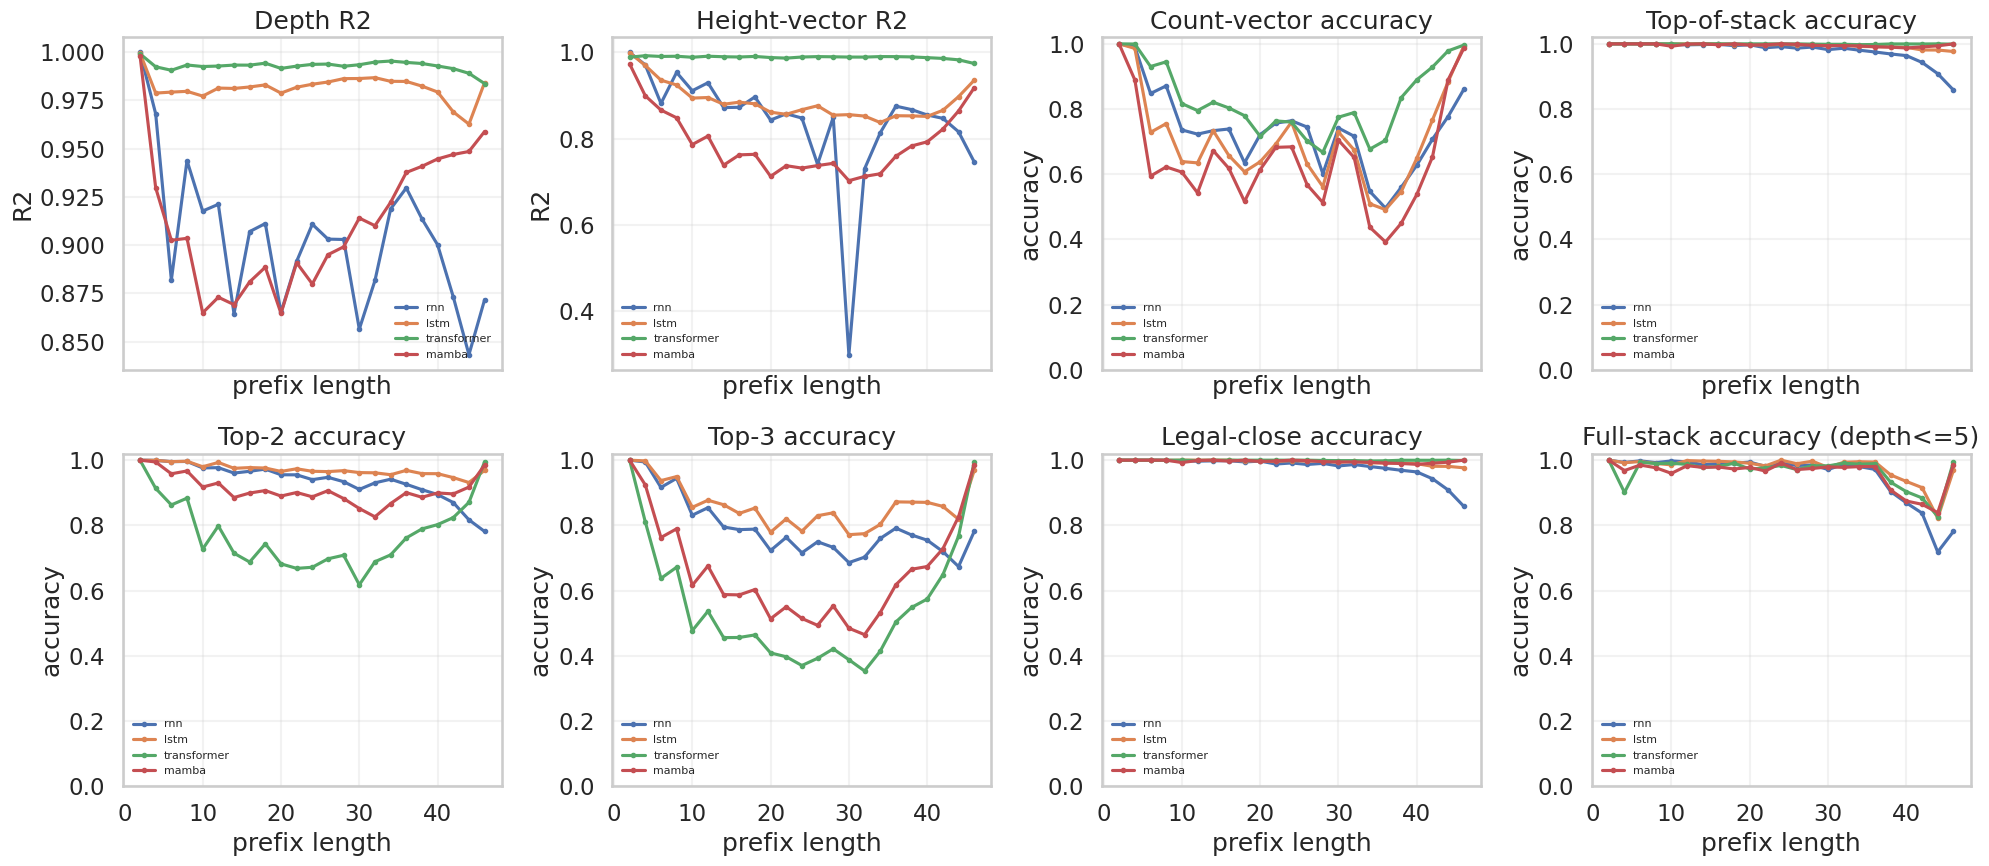

In [15]:
def _rows_to_lookup(rows):
    lookup = {}
    for row in rows:
        lookup[(row["probe"], row["target"], row["metric"])] = row["value"]
    return lookup


def run_prefix_sweep_for_model(model_type):
    model = loaded_models[model_type]["model"]
    state_kind = STATE_KIND_BY_MODEL[model_type]
    sweep_rows = []
    directions = {}

    for prefix_length in SWEEP_PREFIX_LENGTHS:
        print(f"{model_type} prefix={prefix_length}")
        train_data = sample_hidden_stack_matrix(
            model,
            make_sampler(seed_offset=600 + prefix_length),
            prefix_length=prefix_length,
            layer_index=LAYER_INDEX,
            state_kind=state_kind,
            n_samples=SWEEP_N_SAMPLES,
        )
        test_data = sample_hidden_stack_matrix(
            model,
            make_sampler(seed_offset=700 + prefix_length),
            prefix_length=prefix_length,
            layer_index=LAYER_INDEX,
            state_kind=state_kind,
            n_samples=SWEEP_N_SAMPLES,
        )
        train_data = balance_data_by_label(train_data, BALANCE_PROBE_BY, seed=BALANCE_SEED)
        test_data = balance_data_by_label(test_data, BALANCE_PROBE_BY, seed=BALANCE_SEED + 1)

        rows, fitted = run_stack_probes(train_data, test_data)
        lookup = _rows_to_lookup(rows)
        row = {
            "model": model_type,
            "prefix": prefix_length,
            "depth_r2": lookup[("ridge", "depth", "r2")],
            "vector_r2": lookup[("ridge", "height_vector", "r2_mean")],
            "count_vector_acc": lookup[("logistic", "height_vector_class", "accuracy")],
            "top_acc": lookup[("logistic", "top_type_class", "accuracy")],
            "top2_acc": lookup[("logistic", "top_2_class", "accuracy")],
            "top3_acc": lookup[("logistic", "top_3_class", "accuracy")],
            "legal_next_acc": lookup[("logistic", "legal_next_close_type", "accuracy")],
            "full_stack_acc": lookup.get(("logistic", "full_stack_small_class", "accuracy"), float("nan")),
        }
        sweep_rows.append(row)

        directions[prefix_length] = {
            target: _normalize(_ridge_direction(fitted[f"ridge_{target}"]))
            for target in RIDGE_TARGETS
        }
    return sweep_rows, directions


prefix_sweep_results = {}
for model_type in MODEL_TYPES:
    print("=" * 80)
    print(f"PREFIX SWEEP: {model_type}")
    rows, directions = run_prefix_sweep_for_model(model_type)
    prefix_sweep_results[model_type] = {"rows": rows, "directions": directions}


def plot_prefix_sweep(prefix_sweep_results):
    fig, axes = plt.subplots(2, 4, figsize=(20, 9), sharex=True)
    metric_specs = [
        ("depth_r2", "Depth R2", "R2"),
        ("vector_r2", "Height-vector R2", "R2"),
        ("count_vector_acc", "Count-vector accuracy", "accuracy"),
        ("top_acc", "Top-of-stack accuracy", "accuracy"),
        ("top2_acc", "Top-2 accuracy", "accuracy"),
        ("top3_acc", "Top-3 accuracy", "accuracy"),
        ("legal_next_acc", "Legal-close accuracy", "accuracy"),
        ("full_stack_acc", f"Full-stack accuracy (depth<={FULL_STACK_MAX_DEPTH})", "accuracy"),
    ]
    for ax, (key, title, ylabel) in zip(axes.ravel(), metric_specs):
        for model_type, result in prefix_sweep_results.items():
            rows = result["rows"]
            prefixes = np.asarray([r["prefix"] for r in rows])
            vals = np.asarray([r[key] for r in rows])
            ax.plot(prefixes, vals, marker="o", ms=3, label=model_type)
        ax.set_title(title)
        ax.set_xlabel("prefix length")
        ax.set_ylabel(ylabel)
        if ylabel == "accuracy":
            ax.set_ylim(0.0, 1.02)
        ax.grid(True, alpha=0.25)
        ax.legend(frameon=False, fontsize=8)
    plt.tight_layout()
    finalize_figure(fig, section="sweeps", stem="prefix_sweep")


plot_prefix_sweep(prefix_sweep_results)


## 9. Direction Arithmetic


检验：不同括号类型的 counter direction 是否彼此分离，以及 `depth` direction 是否接近三种 per-type height direction 的和。


RNN
prefix | cos(a,b) | cos(a,c) | cos(b,c) | cos(depth,sum)
     2 | -0.634 | -0.969 | +0.518 | +0.628
     4 | -0.892 | -0.965 | +0.894 | +0.972
     6 | +0.755 | +0.694 | +0.864 | +1.000
     8 | -0.310 | -0.183 | +0.731 | +0.983
    10 | +0.021 | -0.089 | +0.972 | +0.958
    12 | +0.102 | +0.115 | +0.783 | +1.000
    14 | -0.787 | -0.605 | +0.864 | +0.998
    16 | -0.870 | -0.833 | +0.731 | -0.355
    18 | -0.482 | +0.287 | +0.048 | +0.803
    20 | -0.016 | +0.643 | -0.354 | +0.948
    22 | -0.356 | -0.542 | +0.290 | +0.938
    24 | -0.360 | -0.417 | +0.342 | +0.979
    26 | -0.122 | +0.087 | -0.145 | +0.986
    28 | -0.591 | -0.584 | +0.091 | +0.942
    30 | -0.210 | +0.324 | -0.056 | +0.924
    32 | -0.238 | -0.405 | -0.523 | +0.834
    34 | -0.327 | -0.138 | -0.761 | +0.843
    36 | -0.393 | -0.779 | -0.120 | +0.933
    38 | -0.709 | -0.944 | +0.732 | +0.977
    40 | -0.796 | -0.247 | -0.028 | +0.978
    42 | +0.467 | -0.822 | -0.617 | +0.164
    44 | +0.843 | -0.855 | -0.901 | 

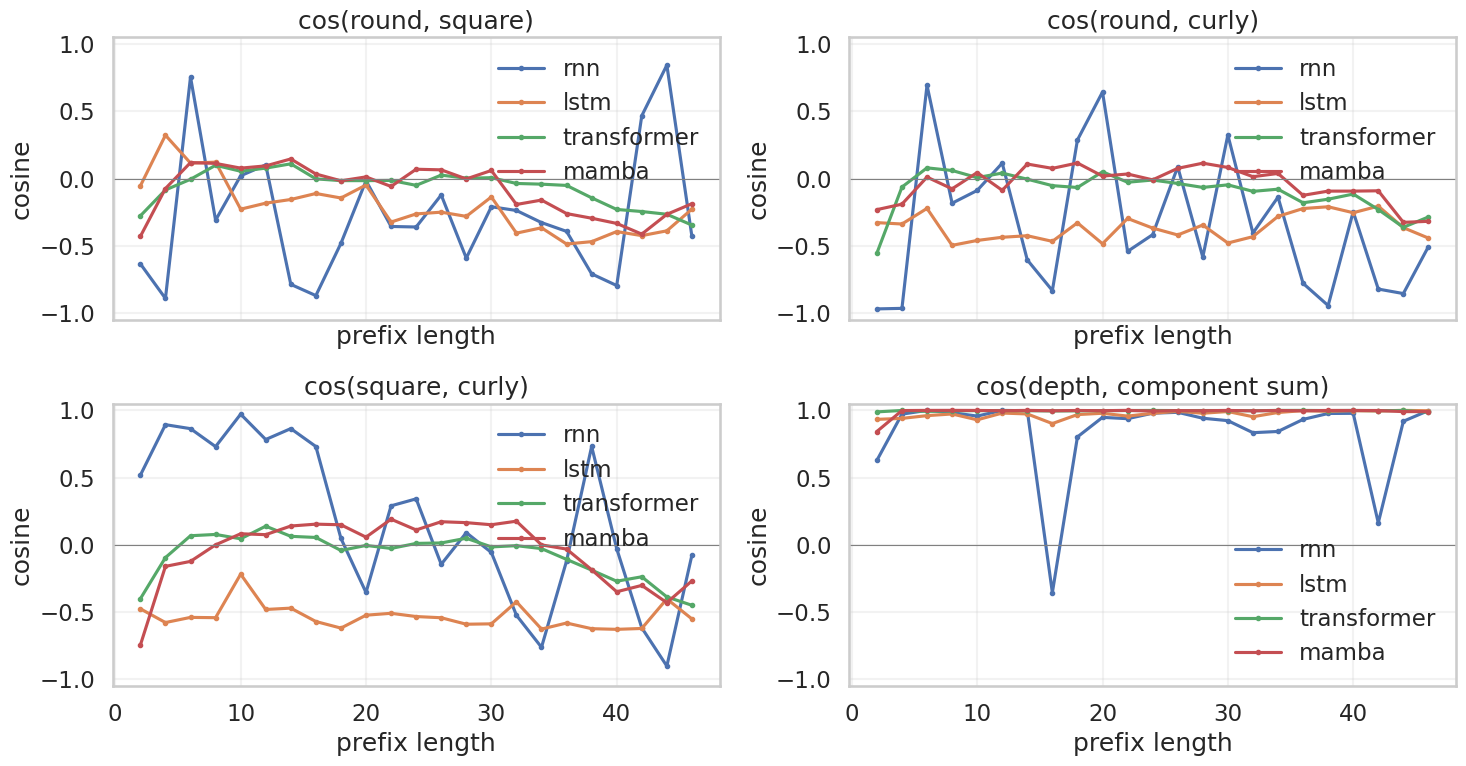

In [16]:
def direction_arithmetic_table(prefix_sweep_results):
    rows = []
    for model_type, result in prefix_sweep_results.items():
        directions = result["directions"]
        for prefix, d in directions.items():
            w_depth = d["depth"]
            w_a = d[COMPONENT_TARGETS[0]]
            w_b = d[COMPONENT_TARGETS[1]]
            w_c = d[COMPONENT_TARGETS[2]]
            w_sum = _normalize(w_a + w_b + w_c)
            rows.append({
                "model": model_type,
                "prefix": prefix,
                "cos_ab": float(np.dot(w_a, w_b)),
                "cos_ac": float(np.dot(w_a, w_c)),
                "cos_bc": float(np.dot(w_b, w_c)),
                "cos_depth_sum": float(np.dot(w_depth, w_sum)),
            })
    return rows


direction_arithmetic_rows = direction_arithmetic_table(prefix_sweep_results)

for model_type in MODEL_TYPES:
    print("=" * 80)
    print(model_type.upper())
    rows = [r for r in direction_arithmetic_rows if r["model"] == model_type]
    print("prefix | cos(a,b) | cos(a,c) | cos(b,c) | cos(depth,sum)")
    for r in rows:
        print(
            f"{r['prefix']:>6d} | {r['cos_ab']:+.3f} | {r['cos_ac']:+.3f} | {r['cos_bc']:+.3f} | {r['cos_depth_sum']:+.3f}"
        )


def plot_direction_arithmetic(direction_arithmetic_rows):
    fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True)
    metrics = [
        ("cos_ab", f"cos({TYPE_NAMES[0]}, {TYPE_NAMES[1]})"),
        ("cos_ac", f"cos({TYPE_NAMES[0]}, {TYPE_NAMES[2]})"),
        ("cos_bc", f"cos({TYPE_NAMES[1]}, {TYPE_NAMES[2]})"),
        ("cos_depth_sum", "cos(depth, component sum)"),
    ]
    for ax, (key, title) in zip(axes.ravel(), metrics):
        for model_type in MODEL_TYPES:
            rows = [r for r in direction_arithmetic_rows if r["model"] == model_type]
            prefixes = [r["prefix"] for r in rows]
            vals = [r[key] for r in rows]
            ax.plot(prefixes, vals, marker="o", ms=3, label=model_type)
        ax.axhline(0, color="gray", lw=0.8)
        ax.set_title(title)
        ax.set_xlabel("prefix length")
        ax.set_ylabel("cosine")
        ax.set_ylim(-1.05, 1.05)
        ax.grid(True, alpha=0.25)
        ax.legend(frameon=False)
    plt.tight_layout()
    finalize_figure(fig, section="sweeps", stem="direction_arithmetic")


plot_direction_arithmetic(direction_arithmetic_rows)
